# NB-04B2 — Auditoría exhaustiva de señales antes del backtest de cartera

## Propósito

Este notebook audita **señal por señal** las entradas generadas por el **NB-04B V4**, antes de construir el NB-de cartera.

La pregunta que responde no es todavía:

> ¿Cuánto gana una cartera de 200.000 USD?

Esa pregunta se vera mas adelante.

La pregunta de este notebook es:

> Si tomo cada señal V4 individualmente, ¿a qué precio entra, cómo evoluciona, cuándo habría salido, por qué motivo sale y qué tipo de pérdidas/ganancias produce?

## Contrato de entrada V4

Una señal long V4 solo es válida si cumple:

- Precio por encima del Kumo actual.
- Kumo actual alcista.
- Kumo futuro alcista.
- Dos velas Heiken Ashi alcistas consecutivas.
- La segunda vela Heiken Ashi está por encima del Kumo.
- Estocástico cruzando desde abajo hacia arriba.
- Volumen confirmado.
- Liquidez suficiente.
- Sin señales fuera del período 2018-2025.

La confirmación Tenkan/Kijun y Chikou se auditan como diagnóstico y priorización, pero no como veto duro en V4.

## Regla de salida auditada

Se simula una salida individual tipo **Core50/Táctico50**:

- 50% táctico.
- 50% core.
- El táctico activa protección si:
  - MFE acumulado >= 5%.
  - Estocástico bajista.
  - Dos velas Heiken Ashi bajistas.
  - Retroceso Fibonacci desde máximo >= 23,6%.
- Una vez activado, el táctico sale por trailing stop de 3%.
- El core sale por invalidación estructural de Ichimoku.

Este notebook genera tablas, gráficos, diagnósticos y exportaciones completas. No depende de mirar solo `.head()`.

In [1]:
# ============================================================
# 0. CONFIGURACIÓN GENERAL
# ============================================================

from pathlib import Path
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

# ------------------------------------------------------------
# Fechas oficiales del análisis histórico
# ------------------------------------------------------------
ANALYSIS_START_DATE = pd.Timestamp("2018-01-01")
ANALYSIS_END_DATE   = pd.Timestamp("2025-12-31")

# ------------------------------------------------------------
# Contrato de entrada
# ------------------------------------------------------------
ENTRY_EXECUTION_MODE = "close_signal"   # "close_signal" o "next_open"
MAX_HOLD_BARS = 80                      # Horizonte máximo de auditoría individual, no de cartera.
TACTICAL_MFE_TRIGGER = 0.05             # 5%
TACTICAL_TRAIL_PCT = 0.03               # 3%
FIB_RETRACE_TRIGGER = 0.236             # 23,6%

# ------------------------------------------------------------
# Salida core
# ------------------------------------------------------------
# 
CORE_EXIT_MODE = "close_below_kumo_bottom"

# ------------------------------------------------------------
# Rutas locales esperadas
# ------------------------------------------------------------
PROJECT_DIR = Path("/Users/rbr/TFM_MVP")

INPUT_04A_DIR = PROJECT_DIR / "outputs_nb04a_sp500_indicators"
INPUT_04B_V4_DIR = PROJECT_DIR / "outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4"

OUTPUT_DIR = PROJECT_DIR / "outputs_nb04b2_signal_audit_v4_pre04c"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# En entorno alternativo, /mnt/data se usa como fallback si existen archivos disponibles.
SANDBOX_DIR = Path("/mnt/data")

print("OUTPUT_DIR:", OUTPUT_DIR)
print("ENTRY_EXECUTION_MODE:", ENTRY_EXECUTION_MODE)
print("CORE_EXIT_MODE:", CORE_EXIT_MODE)

OUTPUT_DIR: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c
ENTRY_EXECUTION_MODE: close_signal
CORE_EXIT_MODE: close_below_kumo_bottom


In [2]:
# ============================================================
# 1. FUNCIONES DE CARGA
# ============================================================

def load_first_existing(paths, description):
    paths = [Path(p) for p in paths]
    existing = [p for p in paths if p.exists()]
    if not existing:
        msg = f"No encontré {description}. Rutas probadas:\n" + "\n".join(str(p) for p in paths)
        raise FileNotFoundError(msg)

    p = existing[0]
    print(f"Cargando {description}: {p}")

    if p.suffix.lower() == ".parquet":
        try:
            return pd.read_parquet(p), p
        except Exception as e:
            print(f"No pude leer parquet ({e}). Intento CSV equivalente si existe...")
            csv_equiv = p.with_suffix(".csv")
            if csv_equiv.exists():
                return pd.read_csv(csv_equiv), csv_equiv
            raise
    elif p.suffix.lower() == ".csv":
        return pd.read_csv(p), p
    elif p.suffix.lower() == ".json":
        with open(p, "r", encoding="utf-8") as f:
            return json.load(f), p
    else:
        raise ValueError(f"Formato no soportado: {p}")

candidate_paths = [
    INPUT_04B_V4_DIR / "df_nb04b_v4_entry_candidates.parquet",
    INPUT_04B_V4_DIR / "df_nb04b_v4_entry_candidates.csv",
    SANDBOX_DIR / "df_nb04b_v4_entry_candidates.parquet",
    SANDBOX_DIR / "df_nb04b_v4_entry_candidates.csv",
]

daily_paths = [
    INPUT_04B_V4_DIR / "df_nb04b_v4_daily_audit.parquet",
    INPUT_04B_V4_DIR / "df_nb04b_v4_daily_audit.csv",
    INPUT_04A_DIR / "sp500_indicators_ichimoku_7_22_44.parquet",
    INPUT_04A_DIR / "sp500_indicators_ichimoku_7_22_44.csv",
    SANDBOX_DIR / "df_nb04b_v4_daily_audit.parquet",
    SANDBOX_DIR / "df_nb04b_v4_daily_audit.csv",
    SANDBOX_DIR / "sp500_indicators_ichimoku_7_22_44.parquet",
    SANDBOX_DIR / "sp500_indicators_ichimoku_7_22_44.csv",
]

df_candidates, path_candidates = load_first_existing(candidate_paths, "candidatos NB-04B V4")
df_daily, path_daily = load_first_existing(daily_paths, "dataset diario para auditoría")

print("Candidatos:", df_candidates.shape)
print("Daily:", df_daily.shape)

display(df_candidates.head(3))
display(df_daily.head(3))

Cargando candidatos NB-04B V4: /Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4/df_nb04b_v4_entry_candidates.parquet
Cargando dataset diario para auditoría: /Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4/df_nb04b_v4_daily_audit.parquet
Candidatos: (8155, 72)
Daily: (990203, 47)


,Ticker,Date,signal_date,candidate_entry_date,entry_timing,delay_days,source_signal_block,entry_family,tk_confirmation_status,chikou_diagnostic_status,accepted_signal,Open_Adj,High_Adj,Low_Adj,Close_Adj,Volume,Volume_Rel,Dollar_Volume_MA20,liquidity_ok,precio_sobre_kumo_actual,precio_dentro_kumo_actual,precio_bajo_kumo_actual,kumo_actual_alcista,kumo_futuro_alcista,kumo_alcista_requerido,kumo_actual_thickness_abs,kumo_actual_thickness_pct,HA_Bullish,HA_Bullish_prev1,HA2_Bullish,HA2_Bullish_sobre_kumo,Stoch_K,Stoch_D,Stoch_K_prev1,Stoch_D_prev1,stoch_cross_up_from_below,stoch_not_extreme_overbought,Ichimoku_Tenkan,Ichimoku_Kijun,tenkan_sobre_kijun,tk_cross_up_today,tk_cross_up_recent,precio_sobre_tenkan,precio_sobre_kijun,precio_sobre_tenkan_y_kijun,Close_22ago,High_22ago,chikou_above_close_22ago,chikou_above_high_22ago,chikou_above_kumo_22ago,Senkou_A_actual,Senkou_B_actual,Kumo_Actual_Top,Kumo_Actual_Bottom,Senkou_A_futuro,Senkou_B_futuro,Kumo_Futuro_Top,Kumo_Futuro_Bottom,technical_priority_score,Year,ret_fwd_5d,mfe_fwd_5d,mae_fwd_5d,ret_fwd_10d,mfe_fwd_10d,mae_fwd_10d,ret_fwd_20d,mfe_fwd_20d,mae_fwd_20d,ret_fwd_40d,mfe_fwd_40d,mae_fwd_40d
0,A,2018-09-13,2018-09-13,2018-09-13,T0,0,T0_HA2_STOCH_KUMO_ACTUAL_Y_FUTURO_ALCISTA_VOLUME,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,True,64.290351,65.763087,64.186504,65.451546,2495000.0,1.258506,1.245360e+08,True,True,False,False,True,True,True,1.548523,0.023659,True,True,True,True,91.891823,84.688613,82.639424,83.246211,True,False,64.394200,63.195245,True,False,False,True,True,True,62.251205,63.242462,True,True,True,62.168576,60.620053,62.168576,60.620053,63.794723,62.218150,63.794723,62.218150,10.5,2018,0.025963,0.026396,-0.013270,0.021203,0.030723,-0.013270,-0.062060,0.046058,-0.065963,-0.020143,0.046058,-0.118143
1,A,2018-10-01,2018-10-01,2018-10-01,T0,0,T0_HA2_STOCH_KUMO_ACTUAL_Y_FUTURO_ALCISTA_VOLUME,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,True,66.867263,67.718715,66.838883,67.415977,2837500.0,1.465817,1.268841e+08,True,True,False,False,True,True,True,1.739704,0.025806,True,True,True,True,92.844453,85.104636,78.146887,78.986956,True,False,66.759779,65.372015,True,False,False,True,True,True,63.261337,63.516230,True,True,True,62.359756,60.620053,62.359756,60.620053,66.065897,64.173059,66.065897,64.173059,10.5,2018,-0.024698,0.015577,-0.032136,-0.079006,0.015577,-0.093180,-0.128824,0.015577,-0.143839,-0.026663,0.015577,-0.143839
2,A,2019-11-15,2019-11-15,2019-11-15,T0,0,T0_HA2_STOCH_KUMO_ACTUAL_Y_FUTURO_ALCISTA_VOLUME,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,True,73.427856,74.745031,73.122424,74.697311,1700400.0,1.352793,9.132719e+07,True,True,False,False,True,True,True,0.945991,0.012664,True,True,True,True,98.516458,80.837186,62.543084,74.163417,True,False,73.475570,72.578362,True,False,False,True,True,True,71.843407,72.425638,True,True,True,71.201762,70.255771,71.201762,70.255771,73.026966,71.729338,73.026966,71.729338,10.5,2019,0.010989,0.015717,-0.012139,0.026706,0.039356,-0.012139,0.079095,0.085867,-0.012139,0.134770,0.141045,-0.012139


,Ticker,Date,Open_Adj,High_Adj,Low_Adj,Close_Adj,Volume,row_operational_ok,Volume_Rel,Dollar_Volume_MA20,liquidity_ok,precio_sobre_kumo_actual,precio_dentro_kumo_actual,precio_bajo_kumo_actual,kumo_actual_alcista,kumo_futuro_alcista,kumo_alcista_requerido,kumo_actual_thickness_abs,kumo_actual_thickness_pct,HA_Bullish,HA_Bullish_prev1,HA2_Bullish,HA2_Bullish_sobre_kumo,Stoch_K,Stoch_D,stoch_cross_up_from_below,stoch_not_extreme_overbought,Ichimoku_Tenkan,Ichimoku_Kijun,tenkan_sobre_kijun,tk_cross_up_today,tk_cross_up_recent,Close_22ago,High_22ago,chikou_above_close_22ago,chikou_above_high_22ago,chikou_above_kumo_22ago,chikou_diagnostic_status,entry_condition_base,entry_event_new_condition,entry_event_after_cooldown,entry_family,technical_priority_score,Senkou_A_actual,Senkou_B_actual,Kumo_Actual_Top,Kumo_Actual_Bottom
0,A,2018-01-02,63.353626,63.795280,63.278450,63.522770,1047800.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,False,False,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN
1,A,2018-01-03,63.541567,65.298775,63.522769,65.139030,1698900.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,True,True,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN
2,A,2018-01-04,65.345748,65.608859,64.631585,64.650383,2230700.0,False,NaN,NaN,False,False,False,False,False,False,False,NaN,NaN,True,True,True,False,NaN,NaN,False,False,NaN,NaN,False,False,False,NaN,NaN,False,False,False,chikou_no_confirmado_o_sin_historia,False,False,False,no_entry,0.0,NaN,NaN,NaN,NaN


In [3]:
# ============================================================
# 2. NORMALIZACIÓN BÁSICA
# ============================================================

def normalize_dates(df):
    df = df.copy()
    for col in ["Date", "signal_date", "candidate_entry_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df

df_candidates = normalize_dates(df_candidates)
df_daily = normalize_dates(df_daily)

# Filtrar período histórico oficial.
df_candidates = df_candidates[
    (df_candidates["Date"] >= ANALYSIS_START_DATE) &
    (df_candidates["Date"] <= ANALYSIS_END_DATE)
].copy()

df_daily = df_daily[
    (df_daily["Date"] >= ANALYSIS_START_DATE) &
    (df_daily["Date"] <= pd.Timestamp("2026-06-30"))  # permite horizonte forward para señales de fin de 2025 si existe en 04A
].copy()

# Ordenar.
df_candidates = df_candidates.sort_values(["Date", "Ticker"]).reset_index(drop=True)
df_daily = df_daily.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Rango candidatos:", df_candidates["Date"].min(), "→", df_candidates["Date"].max())
print("Rango daily:", df_daily["Date"].min(), "→", df_daily["Date"].max())
print("Tickers candidatos:", df_candidates["Ticker"].nunique())
print("Tickers daily:", df_daily["Ticker"].nunique())

# Convertir columnas booleanas típicas.
bool_cols = [
    "accepted_signal",
    "liquidity_ok",
    "precio_sobre_kumo_actual",
    "precio_dentro_kumo_actual",
    "precio_bajo_kumo_actual",
    "kumo_actual_alcista",
    "kumo_futuro_alcista",
    "kumo_alcista_requerido",
    "HA_Bullish",
    "HA_Bullish_prev1",
    "HA2_Bullish",
    "HA2_Bullish_sobre_kumo",
    "stoch_cross_up_from_below",
    "stoch_not_extreme_overbought",
    "tenkan_sobre_kijun",
    "tk_cross_up_today",
    "tk_cross_up_recent",
    "precio_sobre_tenkan",
    "precio_sobre_kijun",
    "precio_sobre_tenkan_y_kijun",
    "chikou_above_close_22ago",
    "chikou_above_high_22ago",
    "chikou_above_kumo_22ago",
]

for df_ in [df_candidates, df_daily]:
    for c in bool_cols:
        if c in df_.columns:
            # robusto para CSV con True/False como string
            if df_[c].dtype == object:
                df_[c] = df_[c].map({
                    True: True, False: False,
                    "True": True, "False": False,
                    "true": True, "false": False,
                    "1": True, "0": False,
                    1: True, 0: False
                }).fillna(False)
            else:
                df_[c] = df_[c].fillna(False).astype(bool)

Rango candidatos: 2018-04-16 00:00:00 → 2025-12-22 00:00:00
Rango daily: 2018-01-02 00:00:00 → 2025-12-31 00:00:00
Tickers candidatos: 502
Tickers daily: 503


## 2. Auditoría de contrato de entrada V4

Esta celda debe detener el notebook si alguna señal incumple condiciones obligatorias.

In [4]:
# ============================================================
# 3. AUDITORÍA DEL CONTRATO DE ENTRADA V4
# ============================================================

required_entry_checks = {
    "precio_sobre_kumo_actual": "La señal long debe estar por encima del Kumo actual.",
    "kumo_actual_alcista": "La nube actual debe ser alcista.",
    "kumo_futuro_alcista": "La nube futura debe ser alcista.",
    "HA2_Bullish": "Debe haber dos velas Heiken Ashi alcistas.",
    "HA2_Bullish_sobre_kumo": "La segunda vela HA alcista debe estar sobre el Kumo.",
    "stoch_cross_up_from_below": "El estocástico debe cruzar desde abajo hacia arriba.",
    "liquidity_ok": "Debe superar filtro de liquidez."
}

audit_rows = []
for col, desc in required_entry_checks.items():
    if col not in df_candidates.columns:
        audit_rows.append({
            "check": col,
            "exists": False,
            "all_true": False,
            "pct_true": np.nan,
            "n_false": np.nan,
            "description": desc
        })
    else:
        pct_true = df_candidates[col].mean()
        n_false = int((~df_candidates[col]).sum())
        audit_rows.append({
            "check": col,
            "exists": True,
            "all_true": bool(n_false == 0),
            "pct_true": pct_true,
            "n_false": n_false,
            "description": desc
        })

df_entry_contract_audit = pd.DataFrame(audit_rows)

display(
    df_entry_contract_audit.style.format({
        "pct_true": "{:.2%}"
    })
)

failed = df_entry_contract_audit[(df_entry_contract_audit["exists"] == False) | (df_entry_contract_audit["all_true"] == False)]
if len(failed) > 0:
    display(failed)
    raise AssertionError("Hay señales que incumplen el contrato de entrada V4. Revisar antes de avanzar.")

if (df_candidates["Date"] > ANALYSIS_END_DATE).any():
    raise AssertionError("Hay señales posteriores al 2025-12-31. No avanzar.")

print("OK: todas las señales candidatas cumplen el contrato de entrada V4.")

,check,exists,all_true,pct_true,n_false,description
0,precio_sobre_kumo_actual,True,True,100.00%,0,La señal long debe estar por encima del Kumo actual.
1,kumo_actual_alcista,True,True,100.00%,0,La nube actual debe ser alcista.
2,kumo_futuro_alcista,True,True,100.00%,0,La nube futura debe ser alcista.
3,HA2_Bullish,True,True,100.00%,0,Debe haber dos velas Heiken Ashi alcistas.
4,HA2_Bullish_sobre_kumo,True,True,100.00%,0,La segunda vela HA alcista debe estar sobre el Kumo.
5,stoch_cross_up_from_below,True,True,100.00%,0,El estocástico debe cruzar desde abajo hacia arriba.
6,liquidity_ok,True,True,100.00%,0,Debe superar filtro de liquidez.


OK: todas las señales candidatas cumplen el contrato de entrada V4.


## 3. Preparación de columnas necesarias para salida

Se calculan columnas auxiliares para identificar deterioro posterior a la entrada:

- Estocástico bajista.
- Dos velas Heiken Ashi bajistas.
- Entrada en Kumo como warning.
- Caída por debajo del Kumo como invalidación estructural core.

In [5]:
# ============================================================
# 4. PREPARACIÓN DE COLUMNAS AUXILIARES EN SERIE DIARIA
# ============================================================

def ensure_price_columns(df):
    df = df.copy()
    # Fallbacks por si el dataset usa nombres sin _Adj.
    mapping = {
        "Open_Adj": ["Open_Adj", "Open"],
        "High_Adj": ["High_Adj", "High"],
        "Low_Adj": ["Low_Adj", "Low"],
        "Close_Adj": ["Close_Adj", "Close", "Adj Close"]
    }
    for target, candidates in mapping.items():
        if target not in df.columns:
            for c in candidates:
                if c in df.columns:
                    df[target] = df[c]
                    break
        if target not in df.columns:
            raise KeyError(f"No encontré columna de precio requerida: {target}")
    return df

def ensure_kumo_columns(df):
    df = df.copy()
    if "Kumo_Actual_Top" not in df.columns:
        if {"Senkou_A_actual", "Senkou_B_actual"}.issubset(df.columns):
            df["Kumo_Actual_Top"] = df[["Senkou_A_actual", "Senkou_B_actual"]].max(axis=1)
            df["Kumo_Actual_Bottom"] = df[["Senkou_A_actual", "Senkou_B_actual"]].min(axis=1)
        else:
            raise KeyError("Faltan Kumo_Actual_Top/Kumo_Actual_Bottom o Senkou_A_actual/Senkou_B_actual.")
    return df

df_daily = ensure_price_columns(df_daily)
df_daily = ensure_kumo_columns(df_daily)

# Heiken Ashi bearish.
if "HA_Bullish" not in df_daily.columns:
    if {"HA_Close", "HA_Open"}.issubset(df_daily.columns):
        df_daily["HA_Bullish"] = df_daily["HA_Close"] > df_daily["HA_Open"]
    else:
        raise KeyError("No encontré HA_Bullish ni HA_Close/HA_Open para calcular Heiken Ashi.")

df_daily["HA_Bearish"] = ~df_daily["HA_Bullish"].fillna(False).astype(bool)
df_daily["HA_Bearish_prev1"] = df_daily.groupby("Ticker")["HA_Bearish"].shift(1).fillna(False)
df_daily["HA2_Bearish"] = df_daily["HA_Bearish"] & df_daily["HA_Bearish_prev1"]

# Estocástico bajista.
if {"Stoch_K", "Stoch_D"}.issubset(df_daily.columns):
    if "Stoch_K_prev1" not in df_daily.columns:
        df_daily["Stoch_K_prev1"] = df_daily.groupby("Ticker")["Stoch_K"].shift(1)
    if "Stoch_D_prev1" not in df_daily.columns:
        df_daily["Stoch_D_prev1"] = df_daily.groupby("Ticker")["Stoch_D"].shift(1)
    df_daily["stoch_cross_down_from_above"] = (
        (df_daily["Stoch_K_prev1"] >= df_daily["Stoch_D_prev1"]) &
        (df_daily["Stoch_K"] < df_daily["Stoch_D"])
    )
    df_daily["stoch_bearish"] = df_daily["Stoch_K"] < df_daily["Stoch_D"]
else:
    raise KeyError("Faltan Stoch_K/Stoch_D.")

# Kumo state.
df_daily["close_above_kumo"] = df_daily["Close_Adj"] > df_daily["Kumo_Actual_Top"]
df_daily["close_inside_kumo"] = (
    (df_daily["Close_Adj"] <= df_daily["Kumo_Actual_Top"]) &
    (df_daily["Close_Adj"] >= df_daily["Kumo_Actual_Bottom"])
)
df_daily["close_below_kumo_bottom"] = df_daily["Close_Adj"] < df_daily["Kumo_Actual_Bottom"]

# Sanidad mínima.
needed_cols = [
    "Ticker", "Date", "Open_Adj", "High_Adj", "Low_Adj", "Close_Adj",
    "Kumo_Actual_Top", "Kumo_Actual_Bottom",
    "HA2_Bearish", "stoch_bearish", "stoch_cross_down_from_above",
    "close_inside_kumo", "close_below_kumo_bottom"
]
missing = [c for c in needed_cols if c not in df_daily.columns]
if missing:
    raise KeyError(f"Faltan columnas necesarias: {missing}")

print("Columnas auxiliares preparadas.")
display(df_daily[needed_cols].head(5))

Columnas auxiliares preparadas.


,Ticker,Date,Open_Adj,High_Adj,Low_Adj,Close_Adj,Kumo_Actual_Top,Kumo_Actual_Bottom,HA2_Bearish,stoch_bearish,stoch_cross_down_from_above,close_inside_kumo,close_below_kumo_bottom
0,A,2018-01-02,63.353626,63.795280,63.278450,63.522770,NaN,NaN,False,False,False,False,False
1,A,2018-01-03,63.541567,65.298775,63.522769,65.139030,NaN,NaN,False,False,False,False,False
2,A,2018-01-04,65.345748,65.608859,64.631585,64.650383,NaN,NaN,False,False,False,False,False
3,A,2018-01-05,64.584613,65.871978,64.584613,65.684044,NaN,NaN,False,False,False,False,False
4,A,2018-01-08,65.524305,66.088116,65.355162,65.825005,NaN,NaN,False,False,False,False,False


## 4. Simulación individual señal por señal

Esta sección evalúa cada señal como una operación independiente, **sin restricciones de cartera**. No es rentabilidad de 200.000 USD.

El objetivo es diagnosticar:

- señales que fallan rápido;
- señales que tuvieron MFE positivo pero devolvieron beneficio;
- señales que entraron bien pero se invalidaron por Kumo;
- señales donde el táctico protegió;
- diferencia entre familias Tenkan/Kijun y Chikou.

In [6]:
# ============================================================
# 5. ÍNDICES POR TICKER PARA AUDITORÍA RÁPIDA
# ============================================================

ticker_data = {}
date_pos = {}

for t, g in df_daily.groupby("Ticker", sort=False):
    gg = g.sort_values("Date").reset_index(drop=True)
    ticker_data[t] = gg
    date_pos[t] = {d: i for i, d in enumerate(gg["Date"].tolist())}

print("Tickers indexados:", len(ticker_data))

Tickers indexados: 503


In [7]:
# ============================================================
# 6. FUNCIONES DE SIMULACIÓN INDIVIDUAL
# ============================================================

def safe_float(x, default=np.nan):
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default

def choose_entry(g, pos):
    row = g.iloc[pos]
    if ENTRY_EXECUTION_MODE == "close_signal":
        return row["Date"], row["Close_Adj"], "close_signal"
    elif ENTRY_EXECUTION_MODE == "next_open":
        if pos + 1 >= len(g):
            return None, np.nan, "no_next_open"
        row_next = g.iloc[pos + 1]
        return row_next["Date"], row_next["Open_Adj"], "next_open"
    else:
        raise ValueError("ENTRY_EXECUTION_MODE debe ser 'close_signal' o 'next_open'.")

def execution_price_for_stop(row, stop_price):
    # Si hay gap bajista bajo el stop, se asume ejecución al Open.
    if row["Open_Adj"] < stop_price:
        return row["Open_Adj"], "gap_open_below_stop"
    return stop_price, "stop_intraday"

def simulate_one_signal(sig, signal_id):
    ticker = sig["Ticker"]
    signal_date = pd.Timestamp(sig["Date"])

    if ticker not in ticker_data or signal_date not in date_pos[ticker]:
        return None, [{
            "signal_id": signal_id, "Ticker": ticker, "Date": signal_date,
            "action": "ERROR", "reason": "ticker_or_date_not_found"
        }]

    g = ticker_data[ticker]
    pos = date_pos[ticker][signal_date]

    entry_date, entry_price, entry_mode = choose_entry(g, pos)
    if entry_date is None or not np.isfinite(entry_price) or entry_price <= 0:
        return None, [{
            "signal_id": signal_id, "Ticker": ticker, "Date": signal_date,
            "action": "ERROR", "reason": "invalid_entry_price"
        }]

    entry_pos = date_pos[ticker].get(pd.Timestamp(entry_date), pos)
    start = entry_pos + 1
    end = min(len(g), entry_pos + 1 + MAX_HOLD_BARS)

    if start >= len(g):
        return None, [{
            "signal_id": signal_id, "Ticker": ticker, "Date": signal_date,
            "action": "ERROR", "reason": "no_future_data"
        }]

    path = g.iloc[start:end].copy()
    if path.empty:
        return None, [{
            "signal_id": signal_id, "Ticker": ticker, "Date": signal_date,
            "action": "ERROR", "reason": "empty_future_path"
        }]

    actions = []
    actions.append({
        "signal_id": signal_id, "Ticker": ticker, "Date": entry_date,
        "action": "ENTRY", "reason": entry_mode,
        "price": entry_price, "position_leg": "CORE50_TACTICAL50"
    })

    peak_high = entry_price
    trough_low = entry_price
    tactical_trail_active = False
    tactical_exit_date = None
    tactical_exit_price = None
    tactical_exit_reason = None
    trailing_stop = np.nan
    trailing_activated_date = None

    core_exit_date = None
    core_exit_price = None
    core_exit_reason = None

    first_inside_kumo_date = None
    first_below_kumo_date = None
    first_stoch_bearish_date = None
    first_ha2_bearish_date = None

    for _, row in path.iterrows():
        dt = row["Date"]
        high = safe_float(row["High_Adj"])
        low = safe_float(row["Low_Adj"])
        close = safe_float(row["Close_Adj"])

        if np.isfinite(high):
            peak_high = max(peak_high, high)
        if np.isfinite(low):
            trough_low = min(trough_low, low)

        mfe_now = (peak_high / entry_price) - 1
        mae_now = (trough_low / entry_price) - 1

        if first_inside_kumo_date is None and bool(row["close_inside_kumo"]):
            first_inside_kumo_date = dt

        if first_below_kumo_date is None and bool(row["close_below_kumo_bottom"]):
            first_below_kumo_date = dt

        if first_stoch_bearish_date is None and bool(row["stoch_bearish"]):
            first_stoch_bearish_date = dt

        if first_ha2_bearish_date is None and bool(row["HA2_Bearish"]):
            first_ha2_bearish_date = dt

        # Retroceso Fibonacci desde máximo alcanzado versus precio de entrada.
        if peak_high > entry_price:
            fib_retrace = (peak_high - close) / (peak_high - entry_price)
        else:
            fib_retrace = 0.0

        stoch_bearish = bool(row["stoch_bearish"])
        stoch_cross_down = bool(row["stoch_cross_down_from_above"])
        ha2_bearish = bool(row["HA2_Bearish"])

        protection_condition = (
            (mfe_now >= TACTICAL_MFE_TRIGGER) and
            stoch_bearish and
            ha2_bearish and
            (fib_retrace >= FIB_RETRACE_TRIGGER)
        )

        if (not tactical_trail_active) and (tactical_exit_date is None) and protection_condition:
            tactical_trail_active = True
            trailing_activated_date = dt
            trailing_stop = peak_high * (1 - TACTICAL_TRAIL_PCT)
            actions.append({
                "signal_id": signal_id, "Ticker": ticker, "Date": dt,
                "action": "TACTICAL_TRAIL_ACTIVATED",
                "reason": "MFE>=5% + Stoch bearish + HA2 bearish + Fibo retrace>=23.6%",
                "price": close,
                "position_leg": "TACTICAL50",
                "mfe_at_activation": mfe_now,
                "fib_retrace": fib_retrace,
                "trailing_stop": trailing_stop
            })

        if tactical_trail_active and tactical_exit_date is None:
            trailing_stop = max(trailing_stop, peak_high * (1 - TACTICAL_TRAIL_PCT))
            if low <= trailing_stop:
                px, stop_exec_mode = execution_price_for_stop(row, trailing_stop)
                tactical_exit_date = dt
                tactical_exit_price = px
                tactical_exit_reason = f"TACTICAL_TRAILING_3PCT_{stop_exec_mode}"
                actions.append({
                    "signal_id": signal_id, "Ticker": ticker, "Date": dt,
                    "action": "TACTICAL_EXIT",
                    "reason": tactical_exit_reason,
                    "price": tactical_exit_price,
                    "position_leg": "TACTICAL50",
                    "trailing_stop": trailing_stop
                })

        # Core exit.
        if core_exit_date is None:
            if CORE_EXIT_MODE == "close_below_kumo_bottom":
                core_invalidated = bool(row["close_below_kumo_bottom"])
                core_reason = "CORE_CLOSE_BELOW_KUMO_BOTTOM"
            elif CORE_EXIT_MODE == "close_inside_or_below_kumo":
                core_invalidated = bool(row["close_inside_kumo"] or row["close_below_kumo_bottom"])
                core_reason = "CORE_CLOSE_NOT_ABOVE_KUMO"
            else:
                raise ValueError("CORE_EXIT_MODE no reconocido.")

            if core_invalidated:
                core_exit_date = dt
                core_exit_price = close
                core_exit_reason = core_reason
                actions.append({
                    "signal_id": signal_id, "Ticker": ticker, "Date": dt,
                    "action": "CORE_EXIT",
                    "reason": core_exit_reason,
                    "price": core_exit_price,
                    "position_leg": "CORE50"
                })

                # Si el táctico seguía abierto, se cierra con el core.
                if tactical_exit_date is None:
                    tactical_exit_date = dt
                    tactical_exit_price = close
                    tactical_exit_reason = "TACTICAL_EXIT_WITH_CORE_INVALIDATION"
                    actions.append({
                        "signal_id": signal_id, "Ticker": ticker, "Date": dt,
                        "action": "TACTICAL_EXIT",
                        "reason": tactical_exit_reason,
                        "price": tactical_exit_price,
                        "position_leg": "TACTICAL50"
                    })
                break

    # Si no hubo salida core dentro del horizonte, cerrar para auditoría al último cierre disponible.
    last_row = path.iloc[-1]
    if core_exit_date is None:
        core_exit_date = last_row["Date"]
        core_exit_price = last_row["Close_Adj"]
        core_exit_reason = "MAX_HOLD_OR_DATA_END"
        actions.append({
            "signal_id": signal_id, "Ticker": ticker, "Date": core_exit_date,
            "action": "CORE_EXIT",
            "reason": core_exit_reason,
            "price": core_exit_price,
            "position_leg": "CORE50"
        })

    if tactical_exit_date is None:
        tactical_exit_date = core_exit_date
        tactical_exit_price = core_exit_price
        tactical_exit_reason = "TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD"
        actions.append({
            "signal_id": signal_id, "Ticker": ticker, "Date": tactical_exit_date,
            "action": "TACTICAL_EXIT",
            "reason": tactical_exit_reason,
            "price": tactical_exit_price,
            "position_leg": "TACTICAL50"
        })

    # Métricas de path completo hasta salida core o fin de horizonte.
    exit_pos = date_pos[ticker].get(pd.Timestamp(core_exit_date), None)
    if exit_pos is not None and exit_pos > entry_pos:
        path_until_exit = g.iloc[entry_pos+1:exit_pos+1]
    else:
        path_until_exit = path

    max_high = max(entry_price, path_until_exit["High_Adj"].max())
    min_low = min(entry_price, path_until_exit["Low_Adj"].min())
    mfe = (max_high / entry_price) - 1
    mae = (min_low / entry_price) - 1

    ret_tactical = (tactical_exit_price / entry_price) - 1
    ret_core = (core_exit_price / entry_price) - 1
    ret_combo = 0.5 * ret_tactical + 0.5 * ret_core

    duration_core_bars = int(max(0, exit_pos - entry_pos)) if exit_pos is not None else len(path_until_exit)
    duration_tactical_bars = None
    tactical_pos = date_pos[ticker].get(pd.Timestamp(tactical_exit_date), None)
    if tactical_pos is not None:
        duration_tactical_bars = int(max(0, tactical_pos - entry_pos))

    result = {
        "signal_id": signal_id,
        "Ticker": ticker,
        "Year": pd.Timestamp(entry_date).year,
        "signal_date": signal_date,
        "entry_date": entry_date,
        "entry_price": entry_price,
        "entry_execution_mode": entry_mode,
        "entry_family": sig.get("entry_family", np.nan),
        "tk_confirmation_status": sig.get("tk_confirmation_status", np.nan),
        "chikou_diagnostic_status": sig.get("chikou_diagnostic_status", np.nan),
        "technical_priority_score": sig.get("technical_priority_score", np.nan),
        "kumo_actual_thickness_pct": sig.get("kumo_actual_thickness_pct", np.nan),
        "Volume_Rel": sig.get("Volume_Rel", np.nan),
        "Stoch_K_entry": sig.get("Stoch_K", np.nan),
        "Stoch_D_entry": sig.get("Stoch_D", np.nan),
        "tactical_exit_date": tactical_exit_date,
        "tactical_exit_price": tactical_exit_price,
        "tactical_exit_reason": tactical_exit_reason,
        "core_exit_date": core_exit_date,
        "core_exit_price": core_exit_price,
        "core_exit_reason": core_exit_reason,
        "trailing_activated": bool(trailing_activated_date is not None),
        "trailing_activated_date": trailing_activated_date,
        "first_inside_kumo_date": first_inside_kumo_date,
        "first_below_kumo_date": first_below_kumo_date,
        "first_stoch_bearish_date": first_stoch_bearish_date,
        "first_ha2_bearish_date": first_ha2_bearish_date,
        "ret_tactical": ret_tactical,
        "ret_core": ret_core,
        "ret_combo": ret_combo,
        "mfe": mfe,
        "mae": mae,
        "mfe_minus_abs_mae": mfe - abs(mae),
        "duration_core_bars": duration_core_bars,
        "duration_tactical_bars": duration_tactical_bars,
        "max_high_until_core_exit": max_high,
        "min_low_until_core_exit": min_low,
    }

    return result, actions

In [8]:
# ============================================================
# 7. EJECUCIÓN DE AUDITORÍA
# ============================================================

results = []
actions_all = []
errors = []

n = len(df_candidates)
print(f"Auditando {n:,} señales V4...")

for i, (_, sig) in enumerate(df_candidates.iterrows(), start=1):
    signal_id = i
    try:
        result, actions = simulate_one_signal(sig, signal_id)
        if result is None:
            errors.extend(actions)
        else:
            results.append(result)
            actions_all.extend(actions)
    except Exception as e:
        errors.append({
            "signal_id": signal_id,
            "Ticker": sig.get("Ticker", None),
            "Date": sig.get("Date", None),
            "action": "ERROR",
            "reason": str(e)
        })

    if i % 1000 == 0:
        print(f"Procesadas {i:,}/{n:,}")

df_signal_trade_audit = pd.DataFrame(results)
df_signal_actions = pd.DataFrame(actions_all)
df_errors = pd.DataFrame(errors)

print("Señales auditadas OK:", len(df_signal_trade_audit))
print("Errores:", len(df_errors))

display(df_signal_trade_audit.head(5))
display(df_errors.head(10))

Auditando 8,155 señales V4...
Procesadas 1,000/8,155
Procesadas 2,000/8,155
Procesadas 3,000/8,155
Procesadas 4,000/8,155
Procesadas 5,000/8,155
Procesadas 6,000/8,155
Procesadas 7,000/8,155
Procesadas 8,000/8,155
Señales auditadas OK: 8155
Errores: 0


,signal_id,Ticker,Year,signal_date,entry_date,entry_price,entry_execution_mode,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,tactical_exit_date,tactical_exit_price,tactical_exit_reason,core_exit_date,core_exit_price,core_exit_reason,trailing_activated,trailing_activated_date,first_inside_kumo_date,first_below_kumo_date,first_stoch_bearish_date,first_ha2_bearish_date,ret_tactical,ret_core,ret_combo,mfe,mae,mfe_minus_abs_mae,duration_core_bars,duration_tactical_bars,max_high_until_core_exit,min_low_until_core_exit
0,1,ALLE,2018,2018-04-16,2018-04-16,77.327362,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.25,0.025532,1.012691,70.748304,64.172432,2018-04-26,71.186096,TACTICAL_EXIT_WITH_CORE_INVALIDATION,2018-04-26,71.186096,CORE_CLOSE_BELOW_KUMO_BOTTOM,False,NaT,2018-04-20,2018-04-26,2018-04-19,2018-04-20,-0.079419,-0.079419,-0.079419,0.019562,-0.115614,-0.096052,8,8,78.840050,68.387206
1,2,BF-B,2018,2018-04-16,2018-04-16,48.735657,close_signal,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.50,0.018204,1.299088,92.963164,88.973063,2018-05-25,50.385691,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-06,45.874676,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-05-23,NaT,2018-06-06,2018-04-17,2018-04-19,0.033857,-0.058704,-0.012424,0.065832,-0.068212,-0.002380,36,29,51.944012,45.411293
2,3,PGR,2018,2018-04-16,2018-04-16,48.036106,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.75,0.031060,1.482174,62.857238,47.500335,2018-06-18,48.808722,TACTICAL_TRAILING_3PCT_gap_open_below_stop,2018-06-25,47.444813,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-18,2018-04-25,2018-06-25,2018-04-18,2018-04-20,0.016084,-0.012309,0.001887,0.063023,-0.046283,0.016741,49,44,51.063499,45.812869
3,4,TECH,2018,2018-04-16,2018-04-16,35.965202,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.75,0.030529,1.044993,78.765093,72.517177,2018-06-21,38.896970,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-27,35.128651,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-21,2018-05-03,2018-06-27,2018-04-19,2018-04-30,0.081517,-0.023260,0.029128,0.114966,-0.042954,0.072012,51,47,40.099970,34.420363
4,5,TKO,2018,2018-04-16,2018-04-16,35.869690,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,11.50,0.060399,1.477004,98.357257,92.187864,2018-08-08,72.043030,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,2018-08-08,72.043030,MAX_HOLD_OR_DATA_END,False,NaT,NaT,NaT,2018-04-17,2018-06-01,1.008465,1.008465,1.008465,1.180787,-0.030395,1.150392,80,80,78.224154,34.779426


""


## 5. Métricas globales, por año y por familia

A partir de aquí, todas las conclusiones salen de **todo el conjunto auditado**.

In [9]:
# ============================================================
# 8. MÉTRICAS AGREGADAS
# ============================================================

def profit_factor(x):
    x = pd.Series(x).dropna()
    gains = x[x > 0].sum()
    losses = x[x < 0].sum()
    if losses == 0:
        return np.inf
    return gains / abs(losses)

def aggregate_metrics(df, group_cols=None):
    if group_cols is None:
        data = df.copy()
        return pd.DataFrame([{
            "n_signals": len(data),
            "n_tickers": data["Ticker"].nunique(),
            "ret_combo_mean": data["ret_combo"].mean(),
            "ret_combo_median": data["ret_combo"].median(),
            "win_rate_combo": (data["ret_combo"] > 0).mean(),
            "profit_factor_combo": profit_factor(data["ret_combo"]),
            "ret_tactical_mean": data["ret_tactical"].mean(),
            "ret_core_mean": data["ret_core"].mean(),
            "mfe_mean": data["mfe"].mean(),
            "mae_mean": data["mae"].mean(),
            "p10_combo": data["ret_combo"].quantile(0.10),
            "p90_combo": data["ret_combo"].quantile(0.90),
            "avg_duration_core_bars": data["duration_core_bars"].mean(),
            "pct_trailing_activated": data["trailing_activated"].mean(),
            "pct_core_invalidated": data["core_exit_reason"].astype(str).str.contains("CORE_CLOSE").mean(),
            "pct_max_hold": (data["core_exit_reason"] == "MAX_HOLD_OR_DATA_END").mean(),
        }])

    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: val for col, val in zip(group_cols, keys)}
        row.update(aggregate_metrics(g).iloc[0].to_dict())
        rows.append(row)
    return pd.DataFrame(rows)

summary_global = aggregate_metrics(df_signal_trade_audit)
summary_by_year = aggregate_metrics(df_signal_trade_audit, ["Year"]).sort_values("Year")
summary_by_family = aggregate_metrics(df_signal_trade_audit, ["entry_family"]).sort_values("ret_combo_mean", ascending=False)
summary_by_tk = aggregate_metrics(df_signal_trade_audit, ["tk_confirmation_status"]).sort_values("ret_combo_mean", ascending=False)
summary_by_chikou = aggregate_metrics(df_signal_trade_audit, ["chikou_diagnostic_status"]).sort_values("ret_combo_mean", ascending=False)
summary_by_core_reason = aggregate_metrics(df_signal_trade_audit, ["core_exit_reason"]).sort_values("n_signals", ascending=False)
summary_by_tactical_reason = aggregate_metrics(df_signal_trade_audit, ["tactical_exit_reason"]).sort_values("n_signals", ascending=False)

fmt_pct_cols = [
    "ret_combo_mean", "ret_combo_median", "win_rate_combo", "ret_tactical_mean", "ret_core_mean",
    "mfe_mean", "mae_mean", "p10_combo", "p90_combo", "pct_trailing_activated", "pct_core_invalidated", "pct_max_hold"
]

display(Markdown("### Resumen global"))
display(summary_global.style.format({c: "{:.2%}" for c in fmt_pct_cols if c in summary_global.columns}))

display(Markdown("### Por año"))
display(summary_by_year.style.format({c: "{:.2%}" for c in fmt_pct_cols if c in summary_by_year.columns}))

display(Markdown("### Por familia de entrada"))
display(summary_by_family.style.format({c: "{:.2%}" for c in fmt_pct_cols if c in summary_by_family.columns}))

display(Markdown("### Por confirmación Tenkan/Kijun"))
display(summary_by_tk.style.format({c: "{:.2%}" for c in fmt_pct_cols if c in summary_by_tk.columns}))

display(Markdown("### Por diagnóstico Chikou"))
display(summary_by_chikou.style.format({c: "{:.2%}" for c in fmt_pct_cols if c in summary_by_chikou.columns}))

### Resumen global

,n_signals,n_tickers,ret_combo_mean,ret_combo_median,win_rate_combo,profit_factor_combo,ret_tactical_mean,ret_core_mean,mfe_mean,mae_mean,p10_combo,p90_combo,avg_duration_core_bars,pct_trailing_activated,pct_core_invalidated,pct_max_hold
0,8155,502,1.53%,-0.00%,49.98%,1.484438,1.03%,2.03%,12.83%,-6.34%,-9.34%,14.08%,46.673207,63.05%,76.24%,23.76%


### Por año

,Year,n_signals,n_tickers,ret_combo_mean,ret_combo_median,win_rate_combo,profit_factor_combo,ret_tactical_mean,ret_core_mean,mfe_mean,mae_mean,p10_combo,p90_combo,avg_duration_core_bars,pct_trailing_activated,pct_core_invalidated,pct_max_hold
0,2018,741.000000,322.000000,-1.07%,-2.47%,38.46%,0.720342,-0.28%,-1.86%,8.23%,-6.40%,-9.55%,7.88%,40.419703,50.47%,87.99%,12.01%
1,2019,1158.000000,417.000000,1.32%,0.87%,53.89%,1.525704,1.21%,1.43%,10.43%,-5.09%,-7.77%,11.66%,50.194301,64.42%,75.22%,24.78%
2,2020,1189.000000,422.000000,2.05%,0.11%,50.21%,1.547246,0.69%,3.42%,15.85%,-7.83%,-11.11%,18.03%,46.575273,67.62%,73.09%,26.91%
3,2021,1335.000000,442.000000,2.19%,0.89%,54.16%,1.775212,1.74%,2.63%,13.49%,-6.41%,-9.02%,15.48%,49.890637,68.09%,74.46%,25.54%
4,2022,472.000000,238.000000,-2.28%,-3.22%,32.63%,0.513300,-1.53%,-3.04%,9.82%,-8.20%,-11.57%,9.59%,38.307203,52.97%,90.04%,9.96%
5,2023,907.000000,382.000000,0.84%,-1.29%,45.09%,1.251978,0.38%,1.29%,11.59%,-6.19%,-8.98%,13.75%,45.324146,59.10%,79.16%,20.84%
6,2024,1429.000000,449.000000,2.94%,1.66%,58.08%,2.156428,2.31%,3.57%,14.58%,-5.43%,-8.26%,14.92%,50.956613,68.86%,76.35%,23.65%
7,2025,924.000000,382.000000,2.68%,-0.24%,49.13%,1.854684,1.19%,4.17%,14.76%,-6.49%,-9.16%,17.10%,41.726190,58.33%,64.61%,35.39%


### Por familia de entrada

,entry_family,n_signals,n_tickers,ret_combo_mean,ret_combo_median,win_rate_combo,profit_factor_combo,ret_tactical_mean,ret_core_mean,mfe_mean,mae_mean,p10_combo,p90_combo,avg_duration_core_bars,pct_trailing_activated,pct_core_invalidated,pct_max_hold
2,v4_kumo_actual_y_futuro_alcista_tk_maduro,5763.000000,501.000000,1.57%,0.23%,50.82%,1.485210,0.97%,2.18%,13.09%,-6.56%,-9.62%,14.13%,48.593961,63.79%,74.94%,25.06%
0,v4_kumo_actual_y_futuro_alcista_con_tk_cross,1652.000000,480.000000,1.48%,-0.25%,48.61%,1.487365,1.15%,1.81%,12.48%,-6.10%,-8.86%,13.82%,43.792978,62.05%,77.91%,22.09%
1,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,740.000000,384.000000,1.28%,-0.70%,46.49%,1.469936,1.17%,1.38%,11.63%,-5.22%,-7.53%,13.67%,38.144595,59.59%,82.57%,17.43%


### Por confirmación Tenkan/Kijun

,tk_confirmation_status,n_signals,n_tickers,ret_combo_mean,ret_combo_median,win_rate_combo,profit_factor_combo,ret_tactical_mean,ret_core_mean,mfe_mean,mae_mean,p10_combo,p90_combo,avg_duration_core_bars,pct_trailing_activated,pct_core_invalidated,pct_max_hold
2,tk_mature_above_kijun_no_recent_cross,5763.000000,501.000000,1.57%,0.23%,50.82%,1.485210,0.97%,2.18%,13.09%,-6.56%,-9.62%,14.13%,48.593961,63.79%,74.94%,25.06%
1,tk_cross_up_recent,1652.000000,480.000000,1.48%,-0.25%,48.61%,1.487365,1.15%,1.81%,12.48%,-6.10%,-8.86%,13.82%,43.792978,62.05%,77.91%,22.09%
0,no_tk_confirmation_yet,740.000000,384.000000,1.28%,-0.70%,46.49%,1.469936,1.17%,1.38%,11.63%,-5.22%,-7.53%,13.67%,38.144595,59.59%,82.57%,17.43%


### Por diagnóstico Chikou

,chikou_diagnostic_status,n_signals,n_tickers,ret_combo_mean,ret_combo_median,win_rate_combo,profit_factor_combo,ret_tactical_mean,ret_core_mean,mfe_mean,mae_mean,p10_combo,p90_combo,avg_duration_core_bars,pct_trailing_activated,pct_core_invalidated,pct_max_hold
0,chikou_libre_sobre_precio_y_kumo_22ago,7657.000000,502.000000,1.57%,0.13%,50.53%,1.494267,1.05%,2.08%,12.98%,-6.41%,-9.50%,14.09%,47.509991,63.61%,75.84%,24.16%
2,chikou_parcial_sobre_close_22ago,218.000000,178.000000,1.55%,-1.05%,44.04%,1.530485,0.75%,2.34%,11.83%,-5.49%,-7.97%,15.63%,37.408257,55.05%,78.90%,21.10%
1,chikou_no_confirmado_o_sin_historia,280.000000,211.000000,0.44%,-1.68%,39.64%,1.151499,0.50%,0.37%,9.68%,-5.11%,-7.64%,13.40%,31.003571,53.93%,85.00%,15.00%


## 6. Diagnóstico de señales negativas

Esta sección no se limita a contar pérdidas: clasifica el tipo de fallo.

In [10]:
# ============================================================
# 9. DIAGNÓSTICO DE NEGATIVOS
# ============================================================

def diagnose_negative(row):
    if row["ret_combo"] >= 0:
        return "positive_or_flat"

    if row["mfe"] < 0.02:
        return "fallo_sin_recorrido_mfe_menor_2pct"

    if row["mfe"] >= TACTICAL_MFE_TRIGGER and not row["trailing_activated"]:
        return "tuvo_mfe_5pct_pero_no_activo_proteccion"

    if row["mfe"] >= TACTICAL_MFE_TRIGGER and row["trailing_activated"]:
        return "tuvo_mfe_5pct_y_trailing_pero_combo_negativo"

    if pd.notna(row["first_below_kumo_date"]):
        days_to_below = (pd.Timestamp(row["first_below_kumo_date"]) - pd.Timestamp(row["entry_date"])).days
        if days_to_below <= 15:
            return "invalidacion_ichimoku_temprana_menor_15d"
        return "invalidacion_ichimoku_posterior"

    if row["mae"] <= -0.08:
        return "mae_profundo_mayor_8pct"

    return "negativo_otro"

df_signal_trade_audit["negative_diagnosis"] = df_signal_trade_audit.apply(diagnose_negative, axis=1)

df_negative_cases = df_signal_trade_audit[df_signal_trade_audit["ret_combo"] < 0].copy()

summary_negative_diagnosis = (
    df_signal_trade_audit
    .groupby("negative_diagnosis", dropna=False)
    .agg(
        n_signals=("signal_id", "count"),
        n_tickers=("Ticker", "nunique"),
        ret_combo_mean=("ret_combo", "mean"),
        ret_combo_median=("ret_combo", "median"),
        mfe_mean=("mfe", "mean"),
        mae_mean=("mae", "mean"),
        avg_duration_core_bars=("duration_core_bars", "mean")
    )
    .reset_index()
    .sort_values("n_signals", ascending=False)
)

summary_negative_diagnosis["pct_total"] = summary_negative_diagnosis["n_signals"] / len(df_signal_trade_audit)

display(Markdown("### Diagnóstico de negativos"))
display(
    summary_negative_diagnosis.style.format({
        "ret_combo_mean": "{:.2%}",
        "ret_combo_median": "{:.2%}",
        "mfe_mean": "{:.2%}",
        "mae_mean": "{:.2%}",
        "pct_total": "{:.2%}"
    })
)

display(Markdown("### Peores 30 casos"))
worst_cases = df_signal_trade_audit.sort_values("ret_combo").head(30)
cols_show = [
    "signal_id", "Ticker", "entry_date", "entry_price",
    "ret_combo", "ret_tactical", "ret_core", "mfe", "mae",
    "core_exit_date", "core_exit_reason",
    "tactical_exit_date", "tactical_exit_reason",
    "entry_family", "tk_confirmation_status", "chikou_diagnostic_status",
    "negative_diagnosis"
]
display(worst_cases[cols_show].style.format({
    "entry_price": "{:.2f}",
    "ret_combo": "{:.2%}",
    "ret_tactical": "{:.2%}",
    "ret_core": "{:.2%}",
    "mfe": "{:.2%}",
    "mae": "{:.2%}"
}))

display(Markdown("### Mejores 30 casos"))
best_cases = df_signal_trade_audit.sort_values("ret_combo", ascending=False).head(30)
display(best_cases[cols_show].style.format({
    "entry_price": "{:.2f}",
    "ret_combo": "{:.2%}",
    "ret_tactical": "{:.2%}",
    "ret_core": "{:.2%}",
    "mfe": "{:.2%}",
    "mae": "{:.2%}"
}))

### Diagnóstico de negativos

,negative_diagnosis,n_signals,n_tickers,ret_combo_mean,ret_combo_median,mfe_mean,mae_mean,avg_duration_core_bars,pct_total
5,positive_or_flat,4077,496,9.37%,6.66%,21.60%,-3.74%,66.388276,49.99%
0,fallo_sin_recorrido_mfe_menor_2pct,1419,464,-8.57%,-7.77%,0.89%,-9.73%,17.930937,17.40%
1,invalidacion_ichimoku_posterior,1363,455,-6.72%,-6.00%,3.42%,-8.06%,30.466618,16.71%
7,tuvo_mfe_5pct_y_trailing_pero_combo_negativo,1154,410,-2.80%,-1.94%,8.81%,-8.96%,35.828423,14.15%
2,invalidacion_ichimoku_temprana_menor_15d,100,92,-9.62%,-8.10%,3.05%,-10.66%,7.460000,1.23%
4,negativo_otro,23,21,-1.98%,-1.64%,2.97%,-4.05%,18.521739,0.28%
6,tuvo_mfe_5pct_pero_no_activo_proteccion,14,13,-9.08%,-8.21%,8.14%,-10.35%,24.000000,0.17%
3,mae_profundo_mayor_8pct,5,5,-5.59%,-5.32%,3.26%,-9.67%,26.200000,0.06%


### Peores 30 casos

,signal_id,Ticker,entry_date,entry_price,ret_combo,ret_tactical,ret_core,mfe,mae,core_exit_date,core_exit_reason,tactical_exit_date,tactical_exit_reason,entry_family,tk_confirmation_status,chikou_diagnostic_status,negative_diagnosis
3496,3497,WBD,2021-03-18 00:00:00,75.95,-45.71%,-45.71%,-45.71%,2.88%,-54.44%,2021-03-29 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2021-03-29 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,invalidacion_ichimoku_temprana_menor_15d
4664,4665,TGT,2022-04-19 00:00:00,213.82,-34.05%,-34.05%,-34.05%,3.58%,-36.66%,2022-05-18 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2022-05-18 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,invalidacion_ichimoku_posterior
2330,2331,FANG,2020-06-08 00:00:00,46.92,-32.75%,-32.75%,-32.75%,0.00%,-33.94%,2020-07-08 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2020-07-08 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,fallo_sin_recorrido_mfe_menor_2pct
2163,2164,DXCM,2020-02-18 00:00:00,74.00,-31.66%,-31.66%,-31.66%,3.62%,-31.76%,2020-03-16 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2020-03-16 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,invalidacion_ichimoku_posterior
20,21,GEN,2018-04-25 00:00:00,13.95,-31.46%,-31.46%,-31.46%,2.53%,-33.81%,2018-05-11 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2018-05-11 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,invalidacion_ichimoku_posterior
2342,2343,MGM,2020-06-08 00:00:00,23.74,-31.39%,-31.39%,-31.39%,0.00%,-35.51%,2020-07-08 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2020-07-08 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,fallo_sin_recorrido_mfe_menor_2pct
7616,7617,ALGN,2025-07-02 00:00:00,196.98,-31.08%,-27.66%,-34.51%,5.75%,-35.17%,2025-07-31 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2025-07-31 00:00:00,TACTICAL_TRAILING_3PCT_gap_open_below_stop,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,tuvo_mfe_5pct_y_trailing_pero_combo_negativo
5801,5802,COIN,2023-12-27 00:00:00,185.24,-30.79%,-30.79%,-30.79%,1.16%,-36.29%,2024-01-31 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2024-01-31 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,fallo_sin_recorrido_mfe_menor_2pct
4044,4045,MRNA,2021-08-09 00:00:00,484.47,-29.60%,-29.60%,-29.60%,2.69%,-33.24%,2021-10-01 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2021-10-01 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,invalidacion_ichimoku_posterior
4702,4703,EQT,2022-06-01 00:00:00,46.95,-29.56%,-29.56%,-29.56%,1.00%,-31.22%,2022-06-22 00:00:00,CORE_CLOSE_BELOW_KUMO_BOTTOM,2022-06-22 00:00:00,TACTICAL_EXIT_WITH_CORE_INVALIDATION,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,fallo_sin_recorrido_mfe_menor_2pct


### Mejores 30 casos

,signal_id,Ticker,entry_date,entry_price,ret_combo,ret_tactical,ret_core,mfe,mae,core_exit_date,core_exit_reason,tactical_exit_date,tactical_exit_reason,entry_family,tk_confirmation_status,chikou_diagnostic_status,negative_diagnosis
7473,7474,WDC,2025-06-09 00:00:00,56.88,130.47%,130.47%,130.47%,141.25%,-4.24%,2025-10-02 00:00:00,MAX_HOLD_OR_DATA_END,2025-10-02 00:00:00,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
6031,6032,VST,2024-02-01 00:00:00,42.54,103.18%,60.03%,146.34%,148.75%,-2.39%,2024-05-28 00:00:00,MAX_HOLD_OR_DATA_END,2024-04-18 00:00:00,TACTICAL_TRAILING_3PCT_gap_open_below_stop,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
7936,7937,SNDK,2025-10-01 00:00:00,121.12,101.66%,107.32%,95.99%,135.11%,-4.49%,2025-12-31 00:00:00,MAX_HOLD_OR_DATA_END,2025-11-19 00:00:00,TACTICAL_TRAILING_3PCT_gap_open_below_stop,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
4,5,TKO,2018-04-16 00:00:00,35.87,100.85%,100.85%,100.85%,118.08%,-3.04%,2018-08-08 00:00:00,MAX_HOLD_OR_DATA_END,2018-08-08 00:00:00,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
7759,7760,LITE,2025-08-06 00:00:00,110.01,99.42%,3.27%,195.57%,195.85%,-1.18%,2025-11-28 00:00:00,MAX_HOLD_OR_DATA_END,2025-08-15 00:00:00,TACTICAL_TRAILING_3PCT_gap_open_below_stop,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
31,32,TKO,2018-05-03 00:00:00,37.61,98.96%,98.96%,98.96%,108.02%,-2.42%,2018-08-27 00:00:00,MAX_HOLD_OR_DATA_END,2018-08-27 00:00:00,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
6898,6899,APP,2024-09-20 00:00:00,126.09,95.81%,28.31%,163.31%,231.22%,-1.19%,2025-01-16 00:00:00,MAX_HOLD_OR_DATA_END,2024-11-04 00:00:00,TACTICAL_TRAILING_3PCT_gap_open_below_stop,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
2760,2761,TPR,2020-09-16 00:00:00,15.94,90.94%,90.94%,90.94%,95.36%,-15.86%,2021-01-11 00:00:00,MAX_HOLD_OR_DATA_END,2021-01-11 00:00:00,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
5177,5178,SMCI,2023-05-03 00:00:00,13.40,86.70%,82.90%,90.49%,166.52%,-2.16%,2023-08-28 00:00:00,MAX_HOLD_OR_DATA_END,2023-06-16 00:00:00,TACTICAL_TRAILING_3PCT_gap_open_below_stop,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat
7782,7783,WDC,2025-08-12 00:00:00,75.72,85.90%,59.28%,112.51%,135.35%,-3.65%,2025-12-04 00:00:00,MAX_HOLD_OR_DATA_END,2025-10-08 00:00:00,TACTICAL_TRAILING_3PCT_gap_open_below_stop,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,positive_or_flat


## 7. Auditorías adicionales: solapamiento, repetición y concentración

Como esta auditoría trata cada señal de forma independiente, puede sobrecontar señales muy cercanas del mismo ticker. Por eso medimos solapamiento y concentración.

In [11]:
# ============================================================
# 10. AUDITORÍA DE SOLAPAMIENTO Y CONCENTRACIÓN
# ============================================================

df_overlap = df_signal_trade_audit.sort_values(["Ticker", "entry_date"]).copy()
df_overlap["prev_entry_date"] = df_overlap.groupby("Ticker")["entry_date"].shift(1)
df_overlap["days_since_prev_signal_same_ticker"] = (
    df_overlap["entry_date"] - df_overlap["prev_entry_date"]
).dt.days

overlap_summary = pd.DataFrame([{
    "n_signals": len(df_overlap),
    "pct_same_ticker_signal_within_5d": (df_overlap["days_since_prev_signal_same_ticker"] <= 5).mean(),
    "pct_same_ticker_signal_within_10d": (df_overlap["days_since_prev_signal_same_ticker"] <= 10).mean(),
    "pct_same_ticker_signal_within_20d": (df_overlap["days_since_prev_signal_same_ticker"] <= 20).mean(),
    "median_days_since_prev_same_ticker": df_overlap["days_since_prev_signal_same_ticker"].median(),
}])

ticker_concentration = (
    df_signal_trade_audit
    .groupby("Ticker")
    .agg(
        n_signals=("signal_id", "count"),
        ret_combo_mean=("ret_combo", "mean"),
        win_rate=("ret_combo", lambda x: (x > 0).mean()),
        mfe_mean=("mfe", "mean"),
        mae_mean=("mae", "mean")
    )
    .reset_index()
    .sort_values("n_signals", ascending=False)
)

display(Markdown("### Solapamiento"))
display(overlap_summary.style.format({
    "pct_same_ticker_signal_within_5d": "{:.2%}",
    "pct_same_ticker_signal_within_10d": "{:.2%}",
    "pct_same_ticker_signal_within_20d": "{:.2%}",
}))

display(Markdown("### Tickers con más señales"))
display(ticker_concentration.head(30).style.format({
    "ret_combo_mean": "{:.2%}",
    "win_rate": "{:.2%}",
    "mfe_mean": "{:.2%}",
    "mae_mean": "{:.2%}"
}))

### Solapamiento

,n_signals,pct_same_ticker_signal_within_5d,pct_same_ticker_signal_within_10d,pct_same_ticker_signal_within_20d,median_days_since_prev_same_ticker
0,8155,2.94%,12.70%,20.87%,70.000000


### Tickers con más señales

,Ticker,n_signals,ret_combo_mean,win_rate,mfe_mean,mae_mean
71,BX,33,3.29%,57.58%,18.64%,-7.12%
319,MSFT,33,1.30%,54.55%,10.58%,-4.56%
42,ARES,32,2.83%,53.12%,13.01%,-6.01%
304,META,31,6.14%,61.29%,20.12%,-7.02%
64,BLDR,31,10.96%,74.19%,29.42%,-6.22%
80,CBOE,30,0.84%,53.33%,10.79%,-4.80%
70,BSX,30,0.03%,36.67%,7.51%,-5.09%
473,VST,30,10.03%,50.00%,32.14%,-7.48%
237,HWM,29,7.31%,62.07%,18.81%,-6.34%
364,PHM,29,1.12%,51.72%,13.42%,-7.08%


## 8. Gráficos agregados

Los gráficos se construyen sobre todo el dataset auditado.

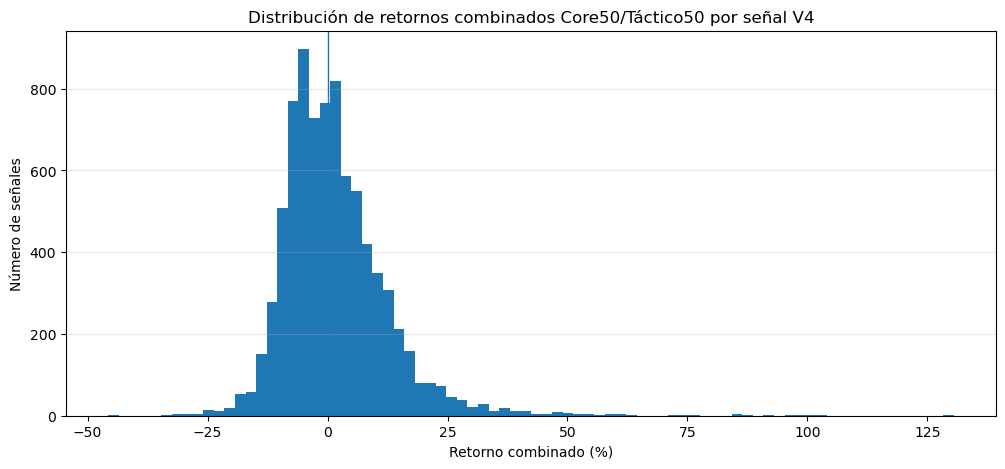

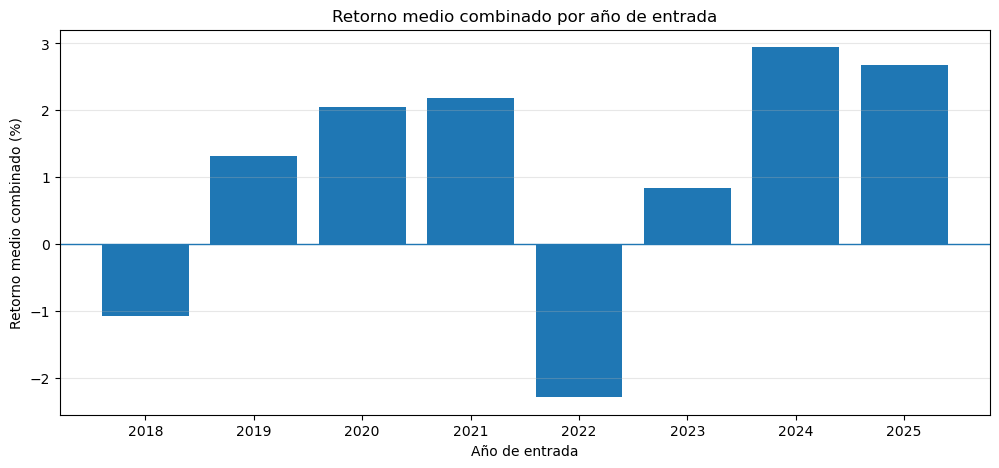

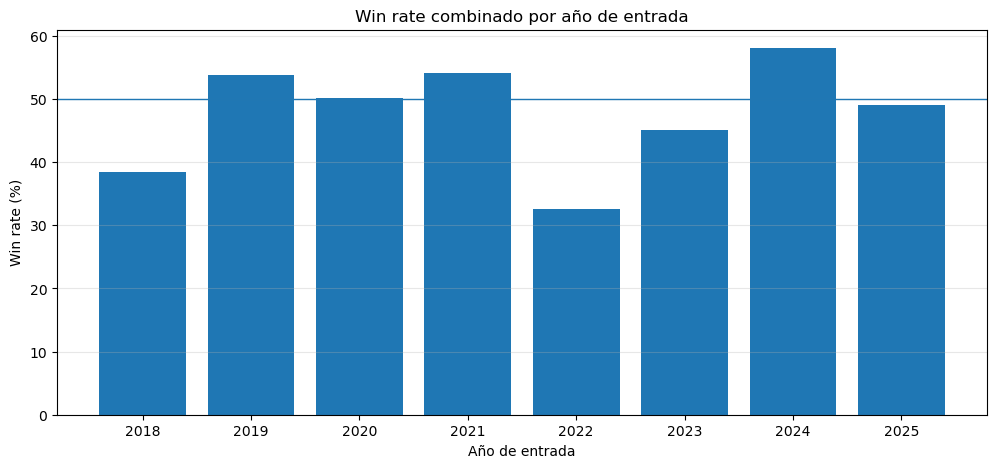

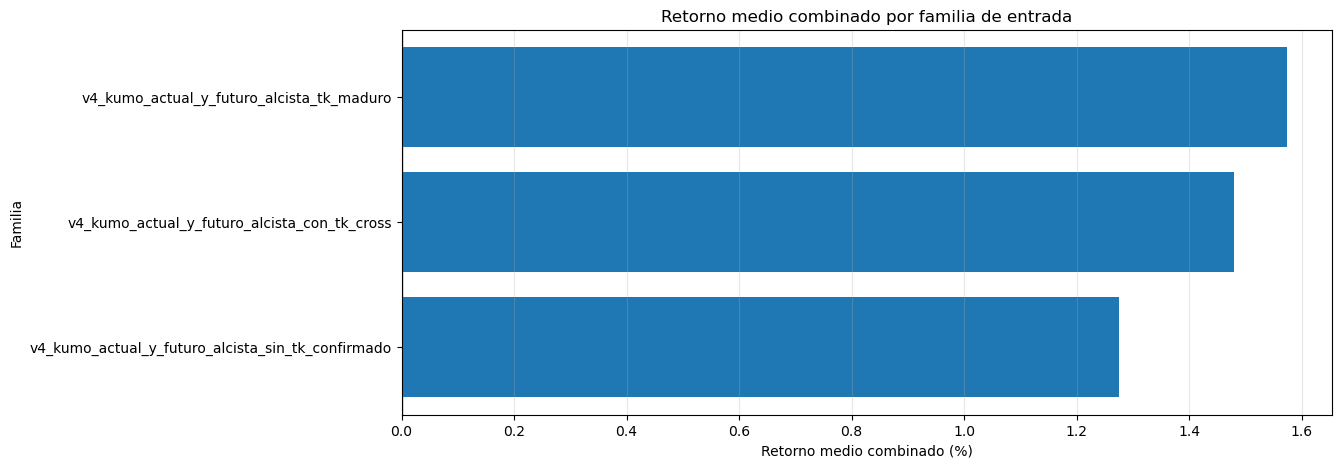

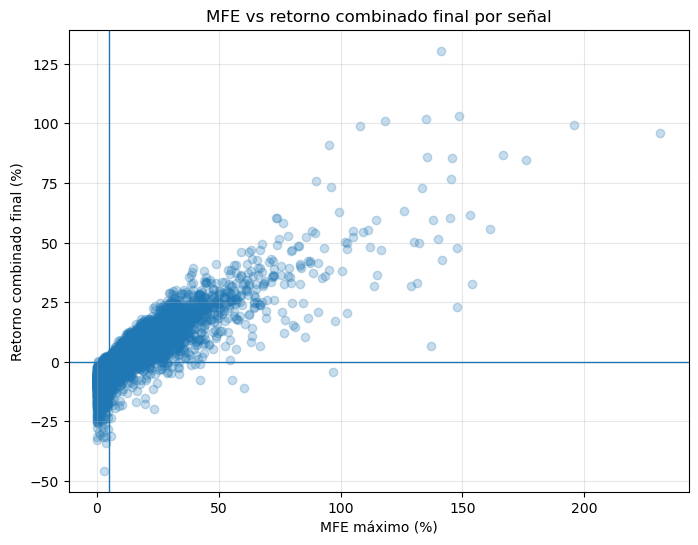

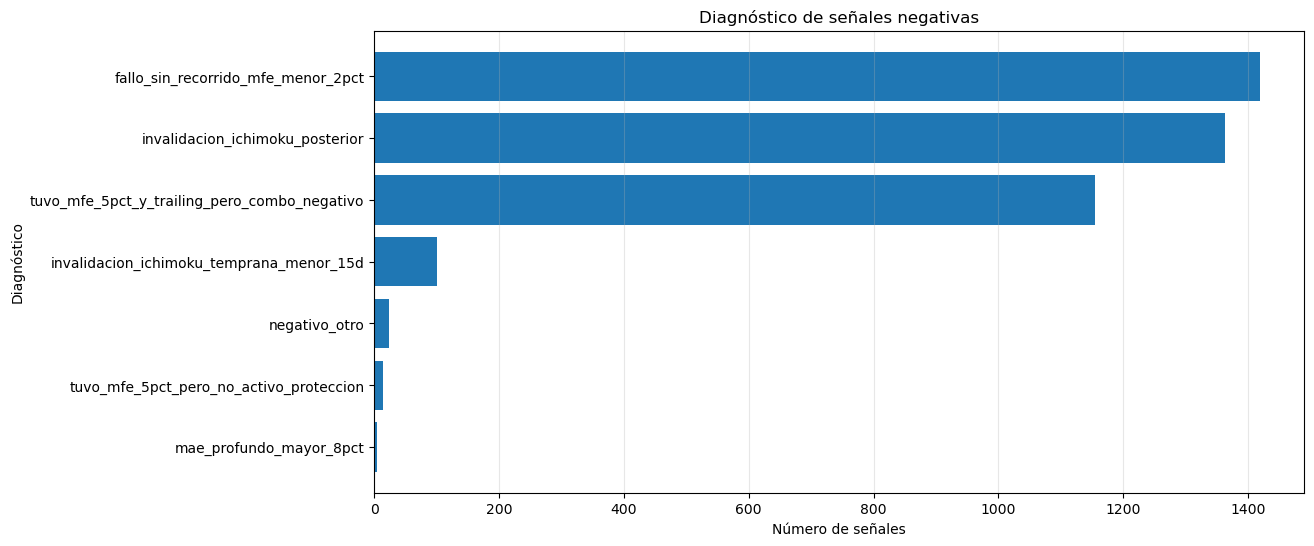

In [12]:
# ============================================================
# 11. GRÁFICOS AGREGADOS
# ============================================================

plt.figure(figsize=(12, 5))
plt.hist(df_signal_trade_audit["ret_combo"].dropna() * 100, bins=80)
plt.axvline(0, linewidth=1)
plt.title("Distribución de retornos combinados Core50/Táctico50 por señal V4")
plt.xlabel("Retorno combinado (%)")
plt.ylabel("Número de señales")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plot_df = summary_by_year.copy()
plt.bar(plot_df["Year"].astype(str), plot_df["ret_combo_mean"] * 100)
plt.axhline(0, linewidth=1)
plt.title("Retorno medio combinado por año de entrada")
plt.xlabel("Año de entrada")
plt.ylabel("Retorno medio combinado (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["Year"].astype(str), plot_df["win_rate_combo"] * 100)
plt.axhline(50, linewidth=1)
plt.title("Win rate combinado por año de entrada")
plt.xlabel("Año de entrada")
plt.ylabel("Win rate (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
fam = summary_by_family.sort_values("ret_combo_mean", ascending=True)
plt.barh(fam["entry_family"].astype(str), fam["ret_combo_mean"] * 100)
plt.axvline(0, linewidth=1)
plt.title("Retorno medio combinado por familia de entrada")
plt.xlabel("Retorno medio combinado (%)")
plt.ylabel("Familia")
plt.grid(axis="x", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df_signal_trade_audit["mfe"] * 100, df_signal_trade_audit["ret_combo"] * 100, alpha=0.25)
plt.axhline(0, linewidth=1)
plt.axvline(TACTICAL_MFE_TRIGGER * 100, linewidth=1)
plt.title("MFE vs retorno combinado final por señal")
plt.xlabel("MFE máximo (%)")
plt.ylabel("Retorno combinado final (%)")
plt.grid(alpha=0.3)
plt.show()

diag_plot = summary_negative_diagnosis[summary_negative_diagnosis["negative_diagnosis"] != "positive_or_flat"].copy()
diag_plot = diag_plot.sort_values("n_signals", ascending=True)
plt.figure(figsize=(12, 6))
plt.barh(diag_plot["negative_diagnosis"].astype(str), diag_plot["n_signals"])
plt.title("Diagnóstico de señales negativas")
plt.xlabel("Número de señales")
plt.ylabel("Diagnóstico")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 9. Función para inspeccionar casos individuales

Usa esta función para revisar señales específicas detectadas como negativas o relevantes.

Ejemplo:

```python
plot_signal_audit(signal_id=123)
```

In [13]:
# ============================================================
# 12. FUNCIÓN DE VISUALIZACIÓN INDIVIDUAL
# ============================================================

def plot_signal_audit(signal_id):
    row = df_signal_trade_audit[df_signal_trade_audit["signal_id"] == signal_id]
    if row.empty:
        raise ValueError(f"No existe signal_id={signal_id}")
    row = row.iloc[0]
    ticker = row["Ticker"]
    entry_date = pd.Timestamp(row["entry_date"])
    core_exit_date = pd.Timestamp(row["core_exit_date"])

    g = ticker_data[ticker].copy()
    start_date = entry_date - pd.Timedelta(days=60)
    end_date = core_exit_date + pd.Timedelta(days=20)
    p = g[(g["Date"] >= start_date) & (g["Date"] <= end_date)].copy()

    plt.figure(figsize=(14, 6))
    plt.plot(p["Date"], p["Close_Adj"], label="Close Adj")
    plt.plot(p["Date"], p["Kumo_Actual_Top"], label="Kumo Top")
    plt.plot(p["Date"], p["Kumo_Actual_Bottom"], label="Kumo Bottom")
    if "Ichimoku_Tenkan" in p.columns:
        plt.plot(p["Date"], p["Ichimoku_Tenkan"], label="Tenkan")
    if "Ichimoku_Kijun" in p.columns:
        plt.plot(p["Date"], p["Ichimoku_Kijun"], label="Kijun")

    plt.axvline(entry_date, linewidth=1, linestyle="--", label="Entry")
    plt.axvline(pd.Timestamp(row["tactical_exit_date"]), linewidth=1, linestyle="--", label="Tactical exit")
    plt.axvline(core_exit_date, linewidth=1, linestyle="--", label="Core exit")

    plt.title(
        f"Signal {signal_id} | {ticker} | Ret combo {row['ret_combo']:.2%} | "
        f"MFE {row['mfe']:.2%} | MAE {row['mae']:.2%}"
    )
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    display(Markdown("### Detalle de señal"))
    display(pd.DataFrame([row]))

    display(Markdown("### Acciones registradas"))
    display(df_signal_actions[df_signal_actions["signal_id"] == signal_id].sort_values("Date"))

# Ejemplo comentado:
# plot_signal_audit(signal_id=int(worst_cases.iloc[0]["signal_id"]))

## 10. Exportaciones

Se exportan los artefactos necesarios para análisis posterior, trazabilidad metodológica y documentación de resultados.

In [14]:
# ============================================================
# 13. EXPORTACIONES
# ============================================================

export_files = {}

def save_csv(df, name):
    path = OUTPUT_DIR / name
    df.to_csv(path, index=False)
    export_files[name] = str(path)
    return path

save_csv(df_signal_trade_audit, "df_nb04b2_v4_signal_trade_audit.csv")
save_csv(df_signal_actions, "df_nb04b2_v4_signal_actions.csv")
save_csv(df_errors, "df_nb04b2_v4_errors.csv")
save_csv(summary_global, "summary_nb04b2_v4_global.csv")
save_csv(summary_by_year, "summary_nb04b2_v4_by_year.csv")
save_csv(summary_by_family, "summary_nb04b2_v4_by_family.csv")
save_csv(summary_by_tk, "summary_nb04b2_v4_by_tk_confirmation.csv")
save_csv(summary_by_chikou, "summary_nb04b2_v4_by_chikou_diagnostic.csv")
save_csv(summary_by_core_reason, "summary_nb04b2_v4_by_core_exit_reason.csv")
save_csv(summary_by_tactical_reason, "summary_nb04b2_v4_by_tactical_exit_reason.csv")
save_csv(df_negative_cases, "df_nb04b2_v4_negative_cases.csv")
save_csv(summary_negative_diagnosis, "summary_nb04b2_v4_negative_diagnosis.csv")
save_csv(overlap_summary, "summary_nb04b2_v4_overlap.csv")
save_csv(ticker_concentration, "summary_nb04b2_v4_ticker_concentration.csv")
save_csv(worst_cases, "df_nb04b2_v4_worst_30_cases.csv")
save_csv(best_cases, "df_nb04b2_v4_best_30_cases.csv")
save_csv(df_entry_contract_audit, "summary_nb04b2_v4_entry_contract_audit.csv")

summary_json = {
    "run_timestamp": pd.Timestamp.now().isoformat(),
    "analysis_start_date": str(ANALYSIS_START_DATE.date()),
    "analysis_end_date": str(ANALYSIS_END_DATE.date()),
    "entry_execution_mode": ENTRY_EXECUTION_MODE,
    "core_exit_mode": CORE_EXIT_MODE,
    "max_hold_bars": MAX_HOLD_BARS,
    "tactical_mfe_trigger": TACTICAL_MFE_TRIGGER,
    "tactical_trail_pct": TACTICAL_TRAIL_PCT,
    "fib_retrace_trigger": FIB_RETRACE_TRIGGER,
    "n_candidates_input": int(len(df_candidates)),
    "n_signals_audited": int(len(df_signal_trade_audit)),
    "n_errors": int(len(df_errors)),
    "n_negative": int((df_signal_trade_audit["ret_combo"] < 0).sum()),
    "pct_negative": float((df_signal_trade_audit["ret_combo"] < 0).mean()),
    "ret_combo_mean": float(df_signal_trade_audit["ret_combo"].mean()),
    "ret_combo_median": float(df_signal_trade_audit["ret_combo"].median()),
    "win_rate_combo": float((df_signal_trade_audit["ret_combo"] > 0).mean()),
    "mfe_mean": float(df_signal_trade_audit["mfe"].mean()),
    "mae_mean": float(df_signal_trade_audit["mae"].mean()),
    "input_files": {
        "candidates": str(path_candidates),
        "daily": str(path_daily)
    },
    "files": export_files
}

summary_json_path = OUTPUT_DIR / "summary_nb04b2_v4.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_json, f, indent=2, default=str)

print("Archivos exportados:")
for k, v in export_files.items():
    print(f"- {k}: {v}")
print("- summary_nb04b2_v4.json:", summary_json_path)

Archivos exportados:
- df_nb04b2_v4_signal_trade_audit.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/df_nb04b2_v4_signal_trade_audit.csv
- df_nb04b2_v4_signal_actions.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/df_nb04b2_v4_signal_actions.csv
- df_nb04b2_v4_errors.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/df_nb04b2_v4_errors.csv
- summary_nb04b2_v4_global.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/summary_nb04b2_v4_global.csv
- summary_nb04b2_v4_by_year.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/summary_nb04b2_v4_by_year.csv
- summary_nb04b2_v4_by_family.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/summary_nb04b2_v4_by_family.csv
- summary_nb04b2_v4_by_tk_confirmation.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/summary_nb04b2_v4_by_tk_confirmation.csv
- summary_nb04b2_v4_by_chikou_diagnostic.csv: /Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/summary_


# Análisis NB-04B2 V4 — Auditoría individual 

## 1. Alcance y advertencia metodológica

Este notebook audita **señal por señal** las entradas generadas por el screener V4.  
No mide todavía una cartera de 200.000 USD. Esa rentabilidad corresponde al futuro **NB-04C**.

Aquí cada señal se evalúa como operación individual con:

- entrada al cierre de la señal;
- posición dividida en Core50/Táctico50;
- salida táctica mediante MFE ≥ 5% + deterioro técnico + trailing 3%;
- salida core por cierre por debajo del borde inferior del Kumo;
- máximo de mantenimiento de 80 ruedas.

La pregunta que responde este notebook es:

> ¿Las señales V4, tomadas individualmente, tienen expectativa positiva y qué tipo de fallos producen?

---

## 2. Auditoría del contrato de entrada

El contrato V4 se cumple correctamente. No hay señales inválidas según las reglas básicas definidas.

| check                     | all_true   | pct_true   |   n_false | description                                          |
|:--------------------------|:-----------|:-----------|----------:|:-----------------------------------------------------|
| precio_sobre_kumo_actual  | True       | 100.00%    |         0 | La señal long debe estar por encima del Kumo actual. |
| kumo_actual_alcista       | True       | 100.00%    |         0 | La nube actual debe ser alcista.                     |
| kumo_futuro_alcista       | True       | 100.00%    |         0 | La nube futura debe ser alcista.                     |
| HA2_Bullish               | True       | 100.00%    |         0 | Debe haber dos velas Heiken Ashi alcistas.           |
| HA2_Bullish_sobre_kumo    | True       | 100.00%    |         0 | La segunda vela HA alcista debe estar sobre el Kumo. |
| stoch_cross_up_from_below | True       | 100.00%    |         0 | El estocástico debe cruzar desde abajo hacia arriba. |
| liquidity_ok              | True       | 100.00%    |         0 | Debe superar filtro de liquidez.                     |

Conclusión: **las pérdidas observadas no vienen de comprar debajo del Kumo ni de incumplir el contrato de entrada**. Vienen de rupturas que cumplen condiciones pero luego no tienen recorrido suficiente, se invalidan o sufren reversión.

---

## 3. Resultado global de la auditoría individual

| Métrica                   | Valor        |
|:--------------------------|:-------------|
| Señales auditadas         | 8.155        |
| Tickers distintos         | 502          |
| Retorno combinado medio   | 1.53%        |
| Retorno combinado mediano | -0.00%       |
| Win rate combinado        | 49.98%       |
| Profit factor combinado   | 1.48         |
| MFE medio                 | 12.83%       |
| MAE medio                 | -6.34%       |
| P10 retorno combinado     | -9.34%       |
| P90 retorno combinado     | 14.08%       |
| Duración core media       | 46.67 ruedas |
| % trailing activado       | 63.05%       |
| % core invalidado         | 76.24%       |
| % max hold / data end     | 23.76%       |

Lectura crítica:

- El retorno medio combinado es positivo: **1.53%**.
- La mediana está prácticamente en cero: **-0.00%**.
- El win rate es prácticamente 50/50: **49.98%**.
- El profit factor es superior a 1: **1.48**.
- El MFE medio, **12.83%**, es bastante superior al MAE medio, **-6.34%**.

Esto confirma que el sistema no gana por acertar siempre. Gana, cuando gana, porque las señales favorables tienen recorrido suficiente para compensar una parte importante de las falsas rupturas.

---

## 4. Resultado por año

|   Year |   n_signals |   n_tickers | ret_combo_mean   | ret_combo_median   | win_rate_combo   |   profit_factor_combo | mfe_mean   | mae_mean   | pct_trailing_activated   |
|-------:|------------:|------------:|:-----------------|:-------------------|:-----------------|----------------------:|:-----------|:-----------|:-------------------------|
|   2018 |         741 |         322 | -1.07%           | -2.47%             | 38.46%           |                  0.72 | 8.23%      | -6.40%     | 50.47%                   |
|   2019 |        1158 |         417 | 1.32%            | 0.87%              | 53.89%           |                  1.53 | 10.43%     | -5.09%     | 64.42%                   |
|   2020 |        1189 |         422 | 2.05%            | 0.11%              | 50.21%           |                  1.55 | 15.85%     | -7.83%     | 67.62%                   |
|   2021 |        1335 |         442 | 2.19%            | 0.89%              | 54.16%           |                  1.78 | 13.49%     | -6.41%     | 68.09%                   |
|   2022 |         472 |         238 | -2.28%           | -3.22%             | 32.63%           |                  0.51 | 9.82%      | -8.20%     | 52.97%                   |
|   2023 |         907 |         382 | 0.84%            | -1.29%             | 45.09%           |                  1.25 | 11.59%     | -6.19%     | 59.10%                   |
|   2024 |        1429 |         449 | 2.94%            | 1.66%              | 58.08%           |                  2.16 | 14.58%     | -5.43%     | 68.86%                   |
|   2025 |         924 |         382 | 2.68%            | -0.24%             | 49.13%           |                  1.85 | 14.76%     | -6.49%     | 58.33%                   |

Conclusiones por año:

- **2024** es el mejor año de la muestra, con retorno medio por señal de **2,94%**.
- **2025** también es positivo, con retorno medio por señal de **2,68%**, aunque mediana ligeramente negativa.
- **2022** es el peor año, con retorno medio por señal de **-2,28%** y win rate de **32,63%**.
- **2018** también queda negativo, con retorno medio de **-1,07%**.

Interpretación: incluso respetando Ichimoku, HA2, estocástico, volumen y Kumo actual/futuro alcista, hay años donde las rupturas fallan con mayor frecuencia. Esto no invalida la señal, pero obliga al 04C a gestionar exposición, priorización y concentración de capital.

---

## 5. Resultado por familia de entrada

| entry_family                                      |   n_signals | ret_combo_mean   | ret_combo_median   | win_rate_combo   |   profit_factor_combo | mfe_mean   | mae_mean   |
|:--------------------------------------------------|------------:|:-----------------|:-------------------|:-----------------|----------------------:|:-----------|:-----------|
| v4_kumo_actual_y_futuro_alcista_tk_maduro         |        5763 | 1.57%            | 0.23%              | 50.82%           |                  1.49 | 13.09%     | -6.56%     |
| v4_kumo_actual_y_futuro_alcista_con_tk_cross      |        1652 | 1.48%            | -0.25%             | 48.61%           |                  1.49 | 12.48%     | -6.10%     |
| v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado |         740 | 1.28%            | -0.70%             | 46.49%           |                  1.47 | 11.63%     | -5.22%     |

Lectura:

- La familia **TK maduro** es la mejor por retorno medio y mediana.
- La familia **con cruce TK reciente** mantiene retorno medio positivo, pero mediana ligeramente negativa.
- La familia **sin TK confirmado** es positiva en promedio, pero tiene menor win rate y peor mediana.

Decisión para 04C: Tenkan/Kijun no debe ser todavía un veto absoluto, pero sí debe entrar como **factor de prioridad**. La señal sin TK confirmado puede mantenerse como candidata secundaria, no como primera preferencia de capital.

---

## 6. Confirmación Tenkan/Kijun

| tk_confirmation_status                |   n_signals | ret_combo_mean   | ret_combo_median   | win_rate_combo   |   profit_factor_combo |
|:--------------------------------------|------------:|:-----------------|:-------------------|:-----------------|----------------------:|
| tk_mature_above_kijun_no_recent_cross |        5763 | 1.57%            | 0.23%              | 50.82%           |                  1.49 |
| tk_cross_up_recent                    |        1652 | 1.48%            | -0.25%             | 48.61%           |                  1.49 |
| no_tk_confirmation_yet                |         740 | 1.28%            | -0.70%             | 46.49%           |                  1.47 |

Conclusión:

- `tk_mature_above_kijun_no_recent_cross` es la condición más estable.
- `tk_cross_up_recent` no domina claramente al TK maduro; puede representar momentos más tempranos o más volátiles.
- `no_tk_confirmation_yet` queda por debajo en calidad.

Para 04C, la prioridad recomendada es:

1. TK maduro.
2. TK cross reciente.
3. Sin TK confirmado, solo si no hay mejores candidatos o si otros factores son fuertes.

---

## 7. Diagnóstico Chikou

| chikou_diagnostic_status               |   n_signals | ret_combo_mean   | ret_combo_median   | win_rate_combo   |   profit_factor_combo |
|:---------------------------------------|------------:|:-----------------|:-------------------|:-----------------|----------------------:|
| chikou_libre_sobre_precio_y_kumo_22ago |        7657 | 1.57%            | 0.13%              | 50.53%           |                  1.49 |
| chikou_parcial_sobre_close_22ago       |         218 | 1.55%            | -1.05%             | 44.04%           |                  1.53 |
| chikou_no_confirmado_o_sin_historia    |         280 | 0.44%            | -1.68%             | 39.64%           |                  1.15 |

Conclusión:

- `chikou_libre_sobre_precio_y_kumo_22ago` es la configuración más sólida.
- `chikou_no_confirmado_o_sin_historia` tiene retorno medio muy bajo y win rate inferior al 40%.
- Chikou no necesita ser todavía un veto universal, pero sí debe penalizar fuertemente el ranking.

Para 04C recomiendo usar Chikou como **filtro de prioridad** y testear una variante que excluya `chikou_no_confirmado_o_sin_historia`.

---

## 8. Salidas core

| core_exit_reason             |   n_signals | ret_combo_mean   | ret_combo_median   | win_rate_combo   |   profit_factor_combo | mfe_mean   | mae_mean   |   avg_duration_core_bars |
|:-----------------------------|------------:|:-----------------|:-------------------|:-----------------|----------------------:|:-----------|:-----------|-------------------------:|
| CORE_CLOSE_BELOW_KUMO_BOTTOM |        6217 | -2.47%           | -2.85%             | 35.26%           |                  0.4  | 8.51%      | -7.08%     |                    37.61 |
| MAX_HOLD_OR_DATA_END         |        1938 | 14.34%           | 11.78%             | 97.21%           |                214.69 | 26.70%     | -3.99%     |                    75.74 |

Esta tabla muestra una diferencia muy importante:

- Cuando el core sale por **cierre debajo del Kumo**, el retorno medio combinado es negativo.
- Cuando llega a **MAX_HOLD_OR_DATA_END**, el retorno medio es muy alto.

Lectura crítica: la regla de core por cierre debajo del Kumo protege la estructura, pero llega después de que muchas señales ya dieron pérdida. Eso no es necesariamente un error, porque el core busca capturar tendencias largas; sin embargo, el 04C debe evitar concentrar demasiado capital en señales que se invalidan rápido.

---

## 9. Salidas tácticas

| tactical_exit_reason                       |   n_signals | ret_combo_mean   | ret_combo_median   | win_rate_combo   |   profit_factor_combo | mfe_mean   | mae_mean   |
|:-------------------------------------------|------------:|:-----------------|:-------------------|:-----------------|----------------------:|:-----------|:-----------|
| TACTICAL_TRAILING_3PCT_gap_open_below_stop |        3291 | 6.89%            | 4.10%              | 73.02%           |                  9.06 | 20.95%     | -5.50%     |
| TACTICAL_EXIT_WITH_CORE_INVALIDATION       |        2881 | -7.76%           | -7.00%             | 0.07%            |                  0    | 2.20%      | -8.99%     |
| TACTICAL_TRAILING_3PCT_stop_intraday       |        1843 | 5.80%            | 4.46%              | 85.57%           |                 26.41 | 14.88%     | -3.88%     |
| TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD          |         140 | 10.36%           | 2.42%              | 67.14%           |                 12.69 | 13.77%     | -4.03%     |

La parte táctica funciona razonablemente bien cuando se activa trailing:

- Las salidas por trailing muestran retorno medio positivo.
- Las salidas tácticas junto con invalidación core son claramente negativas.

Conclusión: el problema principal no está en el trailing cuando hay MFE. El problema aparece en señales que **no alcanzan recorrido suficiente** antes de invalidarse.

---

## 10. Diagnóstico de negativos

| negative_diagnosis                           |   n_signals | ret_combo_mean   | ret_combo_median   | mfe_mean   | mae_mean   |   avg_duration_core_bars | pct_total   |
|:---------------------------------------------|------------:|:-----------------|:-------------------|:-----------|:-----------|-------------------------:|:------------|
| positive_or_flat                             |        4077 | 9.37%            | 6.66%              | 21.60%     | -3.74%     |                    66.39 | 49.99%      |
| fallo_sin_recorrido_mfe_menor_2pct           |        1419 | -8.57%           | -7.77%             | 0.89%      | -9.73%     |                    17.93 | 17.40%      |
| invalidacion_ichimoku_posterior              |        1363 | -6.72%           | -6.00%             | 3.42%      | -8.06%     |                    30.47 | 16.71%      |
| tuvo_mfe_5pct_y_trailing_pero_combo_negativo |        1154 | -2.80%           | -1.94%             | 8.81%      | -8.96%     |                    35.83 | 14.15%      |
| invalidacion_ichimoku_temprana_menor_15d     |         100 | -9.62%           | -8.10%             | 3.05%      | -10.66%    |                     7.46 | 1.23%       |
| negativo_otro                                |          23 | -1.98%           | -1.64%             | 2.97%      | -4.05%     |                    18.52 | 0.28%       |
| tuvo_mfe_5pct_pero_no_activo_proteccion      |          14 | -9.08%           | -8.21%             | 8.14%      | -10.35%    |                    24    | 0.17%       |
| mae_profundo_mayor_8pct                      |           5 | -5.59%           | -5.32%             | 3.26%      | -9.67%     |                    26.2  | 0.06%       |

Conclusión principal:

- El diagnóstico más frecuente es `fallo_sin_recorrido_mfe_menor_2pct`.
- Esto significa que muchas señales técnicamente válidas no llegan siquiera a generar un MFE suficiente antes de deteriorarse.
- La segunda familia crítica es la invalidación Ichimoku posterior.

Esto apunta más a **filtrado/priorización de entrada** que a un problema de salida táctica.

---

## 11. Pruebas adicionales de priorización 

Se evaluaron escenarios simples sobre las señales auditadas para detectar qué variables ayudan a seleccionar mejores candidatos.

| escenario                           |    n |   tickers | mean   | median   | win    |   pf | mfe    | mae    |
|:------------------------------------|-----:|----------:|:-------|:---------|:-------|-----:|:-------|:-------|
| all                                 | 8155 |       502 | 1.53%  | -0.00%   | 49.98% | 1.48 | 12.83% | -6.34% |
| chikou_libre                        | 7657 |       502 | 1.57%  | 0.13%    | 50.53% | 1.49 | 12.98% | -6.41% |
| exclude_no_tk                       | 7415 |       502 | 1.55%  | 0.10%    | 50.33% | 1.49 | 12.95% | -6.46% |
| tk_mature_or_cross_and_chikou_libre | 7162 |       502 | 1.55%  | 0.13%    | 50.53% | 1.48 | 12.99% | -6.49% |
| kumo_thick_gt_median                | 4077 |       499 | 2.35%  | 0.57%    | 52.02% | 1.75 | 15.00% | -6.77% |
| kumo_top40                          | 3262 |       495 | 2.76%  | 0.74%    | 53.22% | 1.89 | 15.88% | -6.89% |
| kumo_top20                          | 1631 |       429 | 3.94%  | 1.62%    | 56.53% | 2.32 | 18.64% | -7.30% |
| volume_gt_1_5                       | 1786 |       474 | 2.38%  | 0.64%    | 52.69% | 1.75 | 14.72% | -6.60% |
| kumo_top40_volume_gt1_5             |  759 |       345 | 3.74%  | 1.25%    | 55.86% | 2.21 | 18.18% | -6.97% |
| core_preferred                      | 3328 |       497 | 2.26%  | 0.42%    | 51.83% | 1.72 | 14.89% | -6.81% |
| strict_preferred                    |  713 |       331 | 4.04%  | 1.60%    | 57.22% | 2.32 | 18.78% | -7.03% |

Lectura fuerte:

- La **profundidad/grosor del Kumo actual** aporta más información que Tenkan/Kijun o Chikou por sí solos.
- El quintil superior de grosor del Kumo alcanza retorno medio de **3,94%**, win rate de **56,53%** y profit factor de **2,32%**.
- `Volume_Rel > 1.5` también mejora el resultado: retorno medio **2,38%** y profit factor **1,75**.
- La combinación de Kumo fuerte + volumen fuerte mejora claramente la expectativa.

---

## 12. Conclusión metodológica

El screener V4 queda validado como base técnica, 

> El contrato V4 genera señales válidas y con expectativa media positiva, pero casi la mitad de las señales no son ganadoras. El valor del sistema no está en acertar siempre, sino en priorizar correctamente las señales con mayor probabilidad de recorrido y en gestionar capital, exposición y salidas.

---



Se testean  cuatro variantes de cartera:

### Variante A — V4 completo
Usa todas las señales V4 válidas. Sirve como baseline.

### Variante B — V4 priorizado
Usa todas las señales, pero ordena por score técnico reforzado:

1. Chikou libre.
2. TK maduro o cruce reciente.
3. Mayor grosor de Kumo actual.
4. Mayor volumen relativo.
5. Mayor MFE potencial/menor riesgo de MAE si se incorpora después.

### Variante C — V4 preferred pool
Usa señales con:
- Chikou libre;
- Kumo actual por encima de la mediana de grosor;
- volumen relativo > 1,1.

Este subconjunto mantiene 3.328 señales, retorno medio de 2.26%, win rate de 51.83% y profit factor de 1.72.

### Variante D — V4 high conviction
Usa señales con:
- Chikou libre;
- Kumo actual en el 40% superior de grosor;
- volumen relativo > 1,5.

Este subconjunto mantiene 713 señales, retorno medio de 4.04%, win rate de 57.22% y profit factor de 2.32.

---



La decisión final se tomará por:

- CAGR;
- retorno acumulado en USD;
- max drawdown;
- profit factor de cartera;
- exposición media;
- años negativos;
- estabilidad entre 2018-2025.




In [ ]:

# ============================================================
# ANÁLISIS ADICIONAL POST-EJECUCIÓN
# ============================================================
# Esta celda resume las pruebas de priorización utilizadas para
# las conclusiones humanas del NB-04B2 V4.
# Se deja aquí para trazabilidad y para poder recalcularlas
# si cambian las señales V4.

import pandas as pd
import numpy as np

audit = pd.read_csv("df_nb04b2_v4_signal_trade_audit.csv")

def metrics(df):
    negsum = abs(df.loc[df.ret_combo < 0, "ret_combo"].sum())
    possum = df.loc[df.ret_combo > 0, "ret_combo"].sum()
    return pd.Series({
        "n": len(df),
        "tickers": df["Ticker"].nunique(),
        "ret_combo_mean": df["ret_combo"].mean(),
        "ret_combo_median": df["ret_combo"].median(),
        "win_rate": (df["ret_combo"] > 0).mean(),
        "profit_factor": possum / negsum if negsum > 0 else np.inf,
        "mfe_mean": df["mfe"].mean(),
        "mae_mean": df["mae"].mean()
    })

kumo_q40 = audit["kumo_actual_thickness_pct"].quantile(0.40)
kumo_q60 = audit["kumo_actual_thickness_pct"].quantile(0.60)

scenarios = {
    "all_v4": audit,
    "chikou_libre": audit[audit["chikou_diagnostic_status"] == "chikou_libre_sobre_precio_y_kumo_22ago"],
    "exclude_no_tk": audit[audit["tk_confirmation_status"] != "no_tk_confirmation_yet"],
    "kumo_thick_gt_median": audit[audit["kumo_actual_thickness_pct"] > audit["kumo_actual_thickness_pct"].median()],
    "volume_gt_1_5": audit[audit["Volume_Rel"] > 1.5],
    "preferred_pool": audit[
        (audit["chikou_diagnostic_status"] == "chikou_libre_sobre_precio_y_kumo_22ago")
        & (audit["kumo_actual_thickness_pct"] > kumo_q40)
        & (audit["Volume_Rel"] > 1.1)
    ],
    "high_conviction_pool": audit[
        (audit["chikou_diagnostic_status"] == "chikou_libre_sobre_precio_y_kumo_22ago")
        & (audit["kumo_actual_thickness_pct"] > kumo_q60)
        & (audit["Volume_Rel"] > 1.5)
    ],
}

summary_priority = pd.DataFrame({k: metrics(v) for k, v in scenarios.items()}).T
display(summary_priority.style.format({
    "ret_combo_mean": "{:.2%}",
    "ret_combo_median": "{:.2%}",
    "win_rate": "{:.2%}",
    "profit_factor": "{:.2f}",
    "mfe_mean": "{:.2%}",
    "mae_mean": "{:.2%}",
}))
